In [72]:
# Libs Load
import pandas as pd
import numpy as np
import os


In [105]:
df_clinical = pd.read_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PDC_info/PDC_Clinical_Tab.csv',index_col=0)
# df_sample_mapping = pd.read_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PDC_info/PDC_info_manifest-20221025.csv',index_col=0)
df_sample_mapping = pd.read_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PDC_info/PDC_info_manifest-20221025.csv')



In [1]:
df_clinical_clean = pd.read_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PDC_info/PDC_Primary_Clinical_TimeCleaned_Tab.csv',index_col=0)
df_clinical_clean

NameError: name 'pd' is not defined

In [ ]:
print(df_clinical.shape)
# 检查映射的CaseID 是否都存在
print((~df_clinical['Case ID'].isin(df_sample_mapping['Case ID'])).sum())
# 将df_sample_mapping种case id 对应的 sample id 加入到df_clinical中
df_clinical = pd.merge(df_clinical, df_sample_mapping, on='Case ID', how='left')
# clinical矩阵去除最后随访时间和死亡时间同时缺失的行
# df_clinical = df_clinical.dropna(subset=['Days to Last Follow Up','Days to Death'])
ids_remove = (df_clinical['Days to Death'].isna() & df_clinical['Days to Last Follow Up'].isna())
print("remove num of samples:",(ids_remove).sum())
df_clinical = df_clinical[~ids_remove]
print(((df_clinical['Days to Death'].isna() & df_clinical['Days to Last Follow Up'].isna()).sum()))
# 去除Solid Tissue Normal样本
df_clinical = df_clinical.loc[df_clinical['Sample Type'] == 'Primary Tumor',:]

In [45]:
(~df_clinical['Days to Death'].isna()).sum()
(df_clinical['Days to Death'].isna()).sum()
(df_clinical['Days to Last Follow Up'].isna()).sum()
# uncensored samples: 408
# censored samples: 1094

177

In [74]:
print((df_clinical['Days to Death'].isna()).sum(),(df_clinical['Days to Last Follow Up'].isna()).sum())

1017 29


In [21]:
print((df_clinical['Days to Death'].isna()).sum(),(df_clinical['Days to Last Follow Up'].isna()).sum())

944 27


In [ ]:
# Sample ∩ Case
# df_clinical['Case ID']



In [80]:
# 遍历所有包含字符串"Proteome"的表达矩阵文件，并读取矩阵文件
proteome_dir="/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/"
num_samples_all=0
for file in os.listdir(proteome_dir):
    # print(file)
    if 'Proteome' in file:
        df_proteome = pd.read_csv(os.path.join(proteome_dir, file), index_col=0)
        # 通过df_clinical 和 proteome 矩阵的交集，得到所有Proteome表达的患者
        num_samples=(df_proteome.columns.isin(df_clinical['Sample ID'])).sum()
        num_samples_all+=num_samples
        if num_samples>10:
            df_proteome=df_proteome.loc[:,df_proteome.columns.isin(df_clinical['Sample ID'])]
            df_proteome.to_csv(os.path.join(proteome_dir, file.replace('.csv', '_filtered.csv')))
            print("num of samples in",file," is :",num_samples)
            print(file, "filtered has been saved")

        elif num_samples>0 and num_samples<=10:
            print("num of samples in",file," is :",num_samples)
            print(file, "too few samples")
print(num_samples_all)
# 15 cancers
# 9cancers
# 1139samples


num of samples in BIC-DDA-Proteome.TMT10.csv  is : 109
BIC-DDA-Proteome.TMT10.csv filtered has been saved
num of samples in CA-DDA-Proteome.TMT10.csv  is : 1
CA-DDA-Proteome.TMT10.csv too few samples
num of samples in CCRCC-DIA-Proteome.Label Free.csv  is : 110
CCRCC-DIA-Proteome.Label Free.csv filtered has been saved
num of samples in HaNSCC-DDA-Proteome.TMT11.csv  is : 104
HaNSCC-DDA-Proteome.TMT11.csv filtered has been saved
num of samples in LA-DDA-Proteome.TMT10.csv  is : 104
LA-DDA-Proteome.TMT10.csv filtered has been saved
num of samples in PDA-DDA-Proteome.TMT11.csv  is : 135
PDA-DDA-Proteome.TMT11.csv filtered has been saved
num of samples in CA-DDA-Proteome.Label Free.csv  is : 4
CA-DDA-Proteome.Label Free.csv too few samples
num of samples in CCRCC-DDA-Proteome.TMT10.csv  is : 110
CCRCC-DDA-Proteome.TMT10.csv filtered has been saved
num of samples in G-DDA-Proteome.TMT11.csv  is : 97
G-DDA-Proteome.TMT11.csv filtered has been saved
num of samples in LSCC-DDA-Proteome.TMT11.c

In [193]:
df_clinical_clean = df_clinical_clean.loc[~((df_clinical_clean['Days to Last Follow Up']<0)|(df_clinical_clean['Days to Death']<0)),:]
# df_clinical.to_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PDC_info/Clinical_Cleaned_Tab.csv', index=False)

In [ ]:
max(df_clinical_clean['Days to Last Follow Up'].max()/365,df_clinical_clean['Days to Death'].max()/365)


15.016438356164384

In [ ]:
time_min=min(df_clinical_clean['Days to Death'].min(),(df_clinical_clean['Days to Last Follow Up']).min())

In [ ]:
max(df_clinical_clean['Days to Last Follow Up'].max()/365,df_clinical_clean['Days to Death'].max()/365)


15.016438356164384

In [124]:
time_min=min(df_clinical_clean['Days to Death'].min(),(df_clinical_clean['Days to Last Follow Up']).min())



In [128]:
df_clinical_clean

,Gender,Race,Primary Diagnosis,Site of Resection or Biopsy,Tissue or Organ of Origin,Tumor Grade,Tumor Stage,Age at Diagnosis,Classification of Tumor,Days to Recurrence,...,Figo Stage,Lymph Nodes Positive,Lymphatic Invasion Present,Residual Disease,Year of Diagnosis,Sample ID,Sample Type,Primary Site_y,Disease Type_y,colSampleName
Case ID,,,,,,,,,,,,,,,,,,,,,
C3L-00004,Male,White,"Renal cell carcinoma, NOS","Kidney, NOS","Kidney, NOS",G3,Stage III,26409.0,NaN,0.0,...,NaN,NaN,NaN,R1,2016.0,CPT0001540009,Primary Tumor,Kidney,Clear Cell Renal Cell Carcinoma,CPT0001540009
C3L-00010,Male,White,"Renal cell carcinoma, NOS","Kidney, NOS","Kidney, NOS",G3,Stage I,11025.0,NaN,0.0,...,NaN,NaN,NaN,R0,2016.0,CPT0001220008,Primary Tumor,Kidney,Clear Cell Renal Cell Carcinoma,CPT0001220008
C3L-00011,Female,White,"Renal cell carcinoma, NOS","Kidney, NOS","Kidney, NOS",G4,Stage IV,23307.0,NaN,0.0,...,NaN,NaN,NaN,R1,2016.0,CPT0001340003,Primary Tumor,Kidney,Clear Cell Renal Cell Carcinoma,CPT0001340003
C3L-00026,Female,White,"Renal cell carcinoma, NOS","Kidney, NOS","Kidney, NOS",G3,Stage I,23881.0,NaN,0.0,...,NaN,NaN,NaN,RX,2016.0,CPT0001500009,Primary Tumor,Kidney,Clear Cell Renal Cell Carcinoma,CPT0001500009
C3L-00079,Male,White,"Renal cell carcinoma, NOS","Kidney, NOS","Kidney, NOS",G3,Stage III,18021.0,NaN,0.0,...,NaN,NaN,NaN,R0,2016.0,CPT0001260009,Primary Tumor,Kidney,Clear Cell Renal Cell Carcinoma,CPT0001260009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AG-3580,Male,NaN,"Adenocarcinoma, NOS",Rectosigmoid junction,Rectosigmoid junction,NaN,Stage I,24775.0,NaN,NaN,...,NaN,NaN,NaN,NaN,2007.0,TCGA-AG-3580-01A-22-2150-27,Primary Tumor,Rectum,Rectum Adenocarcinoma,AG-3580-01A-22
TCGA-AG-A015,Female,NaN,"Adenocarcinoma, NOS","Rectum, NOS","Rectum, NOS",NaN,Stage I,23496.0,NaN,NaN,...,NaN,NaN,NaN,NaN,2009.0,TCGA-AG-A015-01A-51-A20O-27,Primary Tumor,Rectum,Rectum Adenocarcinoma,AG-A015-01A-51
TCGA-AG-A002,Male,NaN,"Adenocarcinoma, NOS","Rectum, NOS","Rectum, NOS",NaN,Stage I,13090.0,NaN,NaN,...,NaN,NaN,NaN,NaN,2009.0,TCGA-AG-A002-01A-23-A20O-27,Primary Tumor,Rectum,Rectum Adenocarcinoma,AG-A002-01A-23


In [190]:
num_neg_time_samples=((df_clinical_clean['Days to Last Follow Up']<0)|(df_clinical_clean['Days to Death']<0)).sum()

In [194]:
# 将df_clinical_clean的 Case ID、Sample ID、Days to Death、Days to Last Follow Up列取出，制作新的矩阵df_label
df_label=df_clinical_clean.loc[:,['Sample ID','Days to Death','Days to Last Follow Up']]
# # 坐标轴矫正
# df_label['Days to Death']=df_label['Days to Death']+abs(time_min)
# df_label['Days to Last Follow Up']=df_label['Days to Last Follow Up']+abs(time_min)
# Time Event
# Death 1 Censored 0
df_label['Event']=(~df_label['Days to Death'].isna()).astype(int)
df_label['Time']=df_label['Days to Death'].fillna(0)+(df_label['Days to Last Follow Up']*(df_label['Days to Death'].isna().astype(int)))
df_label.set_index('Sample ID', inplace=True)
df_label.drop(columns=['Days to Death','Days to Last Follow Up'],inplace=True)
df_label

,Event,Time
Sample ID,,
CPT0001540009,0,384.0
CPT0001220008,0,896.0
CPT0001340003,1,241.0
CPT0001500009,0,1769.0
CPT0001260009,1,274.0
...,...,...
TCGA-AG-3580-01A-22-2150-27,0,244.0
TCGA-AG-A015-01A-51-A20O-27,0,1096.0
TCGA-AG-A002-01A-23-A20O-27,0,638.0


In [195]:
df_label_60 = df_label.loc[df_label['Time']>60,:]
df_label_60.to_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PRO_Pan-cancer_Time>60days_Time-Event.csv')

In [196]:
df_label.to_csv("/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PRO_Pan-cancer_Time-Event.csv")

In [182]:
pd.read_csv("/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PRO_Pan-cancer_Time-Event.csv",index_col=0)
pd.read_csv("/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/PRO_Pan-cancer_Time>60days_Time-Event.csv",index_col=0)


,Event,Time
Sample ID,,
CPT0001540009,0,404.0
CPT0001220008,0,916.0
CPT0001340003,1,261.0
CPT0001500009,0,1789.0
CPT0001260009,1,294.0
...,...,...
TCGA-AG-A00Y-01A-12-A20O-27,0,720.0
TCGA-AF-2691-01A-41-2150-27,0,1329.0
TCGA-AG-3580-01A-22-2150-27,0,264.0


In [284]:
gene2ensg = pd.read_table("/Backup/home/chenyupeng/DATA/biomart_mart_export.txt",index_col='gene')
gene2ensg

,id,GeneType,GeneSynonym
gene,,,
MT-TF,ENSG00000210049,Mt_tRNA,MTTF
MT-TF,ENSG00000210049,Mt_tRNA,trnF
MT-RNR1,ENSG00000211459,Mt_rRNA,12S
MT-RNR1,ENSG00000211459,Mt_rRNA,MOTS-c
MT-RNR1,ENSG00000211459,Mt_rRNA,MTRNR1
...,...,...,...
AC004852.4,ENSG00000284921,lncRNA,NaN
AC004852.6,ENSG00000285440,processed_pseudogene,NaN
AC004852.5,ENSG00000285110,processed_pseudogene,NaN


In [310]:
proteome_dir="/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/"

for file in os.listdir(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/"):
    if "filtered" in file:
        print(file)
        fm = pd.read_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/{file}",index_col=0)
        print("before",fm.shape)
        gene_set = fm.index[fm.index.isin(gene2ensg.index)].unique()
        fm = fm.loc[gene_set]
        ensg_ids=gene2ensg.loc[gene_set,'id']
        ensg_ids=ensg_ids[~ensg_ids.index.duplicated()]
        fm.set_index(ensg_ids,inplace=True)
        os.makedirs(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/",exist_ok=True)
        fm.to_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/{file}")
        print(f"Successfully processed and saved {file}")
        print("after",fm.shape)

CCRCC-DIA-Proteome.Label Free_filtered.csv
before (3161, 110)
Successfully processed and saved CCRCC-DIA-Proteome.Label Free_filtered.csv
after (3108, 110)
HaNSCC-DDA-Proteome.TMT11_filtered.csv
before (10250, 104)
Successfully processed and saved HaNSCC-DDA-Proteome.TMT11_filtered.csv
after (10115, 104)
LA-DDA-Proteome.TMT10_filtered.csv
before (11029, 104)
Successfully processed and saved LA-DDA-Proteome.TMT10_filtered.csv
after (10890, 104)
LSCC-DDA-Proteome.TMT11_filtered.csv
before (11485, 103)
Successfully processed and saved LSCC-DDA-Proteome.TMT11_filtered.csv
after (11344, 103)
OSC-DDA-Proteome.TMT10_filtered.csv
before (9841, 167)
Successfully processed and saved OSC-DDA-Proteome.TMT10_filtered.csv
after (9633, 167)
BIC-DDA-Proteome.TMT10_filtered.csv
before (12184, 109)
Successfully processed and saved BIC-DDA-Proteome.TMT10_filtered.csv
after (10386, 109)
PDA-DDA-Proteome.TMT11_filtered.csv
before (10116, 135)
Successfully processed and saved PDA-DDA-Proteome.TMT11_filtered

In [290]:
gene_set = fm.index[fm.index.isin(gene2ensg.index)].unique()

In [295]:
gene_set

Index(['A1BG', 'A2M', 'A2ML1', 'A4GALT', 'AAAS', 'AACS', 'AADAT', 'AAGAB',
       'AAK1', 'AAMDC',
       ...
       'ZSWIM9', 'ZUP1', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDC', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', name='Gene', length=10629)

In [308]:
ensg_ids=gene2ensg.loc[gene_set,'id']
ensg_ids=ensg_ids[~ensg_ids.index.duplicated()]

Gene
A1BG      ENSG00000121410
A2M       ENSG00000175899
A2ML1     ENSG00000166535
A4GALT    ENSG00000128274
AAAS      ENSG00000094914
               ...       
ZXDA      ENSG00000198205
ZXDC      ENSG00000070476
ZYG11B    ENSG00000162378
ZYX       ENSG00000159840
ZZEF1     ENSG00000074755
Name: id, Length: 10629, dtype: object

In [210]:
(fm.index.isin(gene2ensg['gene'])).sum()

10629

In [211]:
len(fm.index)

10768

In [236]:
gene2ensg

,GeneType,gene,GeneSynonym
id,,,
ENSG00000210049,Mt_tRNA,MT-TF,MTTF
ENSG00000210049,Mt_tRNA,MT-TF,trnF
ENSG00000211459,Mt_rRNA,MT-RNR1,12S
ENSG00000211459,Mt_rRNA,MT-RNR1,MOTS-c
ENSG00000211459,Mt_rRNA,MT-RNR1,MTRNR1
...,...,...,...
ENSG00000284921,lncRNA,AC004852.4,NaN
ENSG00000285440,processed_pseudogene,AC004852.6,NaN
ENSG00000285110,processed_pseudogene,AC004852.5,NaN


In [241]:
gene2ensg = pd.concat([gene2ensg.drop(columns='gene').rename(columns={'GeneSynonym': 'gene'}),gene2ensg.drop(columns='GeneSynonym')], axis=0,)
gene2ensg

,GeneType,gene
id,,
ENSG00000210049,Mt_tRNA,MTTF
ENSG00000210049,Mt_tRNA,trnF
ENSG00000211459,Mt_rRNA,12S
ENSG00000211459,Mt_rRNA,MOTS-c
ENSG00000211459,Mt_rRNA,MTRNR1
...,...,...
ENSG00000284921,lncRNA,AC004852.4
ENSG00000285440,processed_pseudogene,AC004852.6
ENSG00000285110,processed_pseudogene,AC004852.5


In [242]:
gene2ensg.dropna(inplace=True)
gene2ensg

,GeneType,gene
id,,
ENSG00000210049,Mt_tRNA,MTTF
ENSG00000210049,Mt_tRNA,trnF
ENSG00000211459,Mt_rRNA,12S
ENSG00000211459,Mt_rRNA,MOTS-c
ENSG00000211459,Mt_rRNA,MTRNR1
...,...,...
ENSG00000284921,lncRNA,AC004852.4
ENSG00000285440,processed_pseudogene,AC004852.6
ENSG00000285110,processed_pseudogene,AC004852.5


In [249]:
gene2ensg.drop_duplicates(inplace=True)
gene2ensg

,GeneType,gene
id,,
ENSG00000210049,Mt_tRNA,MTTF
ENSG00000210049,Mt_tRNA,trnF
ENSG00000211459,Mt_rRNA,12S
ENSG00000211459,Mt_rRNA,MOTS-c
ENSG00000211459,Mt_rRNA,MTRNR1
...,...,...
ENSG00000286706,lncRNA,AC008180.1
ENSG00000285949,lncRNA,AC084784.1
ENSG00000284921,lncRNA,AC004852.4


In [250]:
gene2ensg.to_csv("/Backup/home/chenyupeng/DATA/gene2ensg_MergeGeneSynonym.csv")

In [233]:
gene_set = fm.index[(fm.index.isin(gene2ensg['gene']))].to_list()
GeneSyn_set = fm.index[(fm.index.isin(gene2ensg['GeneSynonym']))].to_list()

In [225]:
# 合并集合
gene_list = sorted(list(set(gene_set+GeneSyn_set)))

In [227]:
fm.loc[gene_list,:]

,CPT0078320004,CPT0080610003,CPT0027420003,CPT0026030004,CPT0080300003,CPT0027810003,CPT0002430011,CPT0080880003,CPT0022830003,CPT0016370003,...,CPT0064150004,CPT0002080011,CPT0002010011,CPT0024130003,CPT0070260003,CPT0080030003,CPT0066620003,CPT0000730011,CPT0001300009,CPT0027650003
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,-0.430878,0.712297,-0.409964,0.171747,-0.160983,-0.473205,-1.048933,0.018008,-0.154760,-0.368323,...,-0.649967,-0.182495,-1.102698,-0.305286,-0.157360,0.433998,-0.045146,-1.003187,-0.716958,-1.154776
A2M,-0.337151,1.296936,0.458096,-0.102974,-0.361188,-0.501375,-1.397337,0.043013,0.206281,-0.682405,...,-0.937105,-0.098494,-0.714052,0.092416,0.271822,0.973028,-0.372298,-0.604268,-0.826639,-0.741170
A2ML1,1.319163,-0.642514,-0.357449,-0.740883,0.259748,-0.970202,-0.500977,-0.607933,0.158378,-0.569490,...,2.635396,-0.249828,-1.463966,-0.087348,0.816588,-0.974288,-1.369173,-0.735984,-0.453186,-0.074100
A4GALT,0.144793,0.283678,0.304450,0.173191,-0.393664,0.063540,NaN,NaN,NaN,NaN,...,0.913318,1.296900,-0.085163,0.290115,0.155838,0.685488,-0.023506,-0.363788,0.865229,-0.048572
AAAS,0.157970,0.063177,0.327417,-0.115628,-0.135141,-0.174413,0.148773,-0.763340,-0.155658,-0.057612,...,0.003464,-0.116211,0.297625,0.143912,0.551638,0.144143,-0.054519,-0.040139,0.255636,0.184994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDA,-0.322869,-0.133026,-0.431440,-0.219434,0.484513,0.068379,-3.585404,-0.021334,-1.517693,-0.292139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZXDC,-0.150091,-0.298616,0.380817,-0.037516,-0.345975,0.219119,-0.229672,0.685040,-0.436412,-0.104663,...,-0.186096,-0.535731,-0.513812,-0.545846,-0.815602,0.512158,-0.773914,0.390004,-0.104181,-0.589301
ZYG11B,-0.091193,-0.077680,-0.315642,0.230698,0.377083,-0.454890,-0.328831,0.904839,0.092085,0.006020,...,0.049718,0.084711,0.127293,-0.140589,-0.081088,-0.124867,0.048496,-0.295554,0.052922,0.187488


In [254]:
gene2ensg=pd.read_csv("/Backup/home/chenyupeng/DATA/gene2ensg_MergeGeneSynonym.csv")

In [255]:
gene2ensg

,id,GeneType,gene
0,ENSG00000210049,Mt_tRNA,MTTF
1,ENSG00000210049,Mt_tRNA,trnF
2,ENSG00000211459,Mt_rRNA,12S
3,ENSG00000211459,Mt_rRNA,MOTS-c
4,ENSG00000211459,Mt_rRNA,MTRNR1
...,...,...,...
114997,ENSG00000286706,lncRNA,AC008180.1
114998,ENSG00000285949,lncRNA,AC084784.1
114999,ENSG00000284921,lncRNA,AC004852.4
115000,ENSG00000285440,processed_pseudogene,AC004852.6


In [258]:
gene2ensg.set_index('gene', inplace=True,drop=True)

In [262]:
ensg_ids=gene2ensg.loc[gene_list,'id']

In [275]:
ensg_ids.index.duplicated().__len__()

10791

In [276]:
ensg_ids.__len__()

10791

In [282]:
ensg_ids[ensg_ids.index.duplicated(keep=False)]

gene
ATR       ENSG00000169604
ATR       ENSG00000258597
C4B       ENSG00000244731
C4B       ENSG00000224639
CABIN1    ENSG00000281670
               ...       
TTL       ENSG00000114999
VDAC3     ENSG00000270858
VDAC3     ENSG00000078668
WDR82     ENSG00000234629
WDR82     ENSG00000164091
Name: id, Length: 69, dtype: object

In [264]:
fm.shape

(10768, 95)

In [265]:
len(gene_list)

10756

In [263]:
fm.set_index(ensg_ids)

ValueError: Length mismatch: Expected 10768 rows, received array of length 10791

In [231]:
((gene2ensg['GeneSynonym'].isin(gene_list))|(gene2ensg['gene'].isin(gene_list))).sum()

30999

In [ ]:
# 正态分布检验
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
def norm_test(df):
    '''
    gene*sample
    '''
    data = np.matrix(df).ravel().tolist()
    data = np.random.choice(np.squeeze(data), size=10000000)
    print(data[~np.isnan(data)].std())
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data, fill=True)
    plt.xlabel('Expression')
    plt.ylabel('Frequency')
    plt.title('Distribution of Distances in Gene Co-expression Matrix')
    plt.show()
    # plt.savefig(f'Expression_distribution_{}.pdf')

In [10]:
os.listdir('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/')

AttributeError: module 'os' has no attribute 'listfiles'

In [5]:
import os 
for file in os.listdir('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/'):
    try:
        df = pd.read_csv(f'/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/{file}',index_col=0)
        print(file)

    except:
        # 下一个循环
        continue
    print(df.shape)
    # norm_test(df)

LSCC-DDA-Proteome.TMT11_filtered.csv
(11344, 103)
OSC-DDA-Proteome.TMT10_filtered.csv
(9633, 167)
BIC-DDA-Proteome.TMT10_filtered.csv
(10386, 109)
CCRCC-DDA-Proteome.TMT10_filtered.csv
(9830, 110)
G-DDA-Proteome.TMT11_filtered.csv
(10837, 97)
CCRCC-DIA-Proteome.Label Free_filtered.csv
(3108, 110)
HaNSCC-DDA-Proteome.TMT11_filtered.csv
(10115, 104)
LA-DDA-Proteome.TMT10_filtered.csv
(10890, 104)
PDA-DDA-Proteome.TMT11_filtered.csv
(9979, 135)
UCEC-DDA-Proteome.TMT10_filtered.csv
(10629, 95)


In [1]:

dir_path ="/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/0.5nafilter_CoxSort/STRING/"
import os 
import pandas as pd
for dirs in os.listdir(dir_path):
    
    df = pd.read_csv(f'{dir_path}{dirs}/dataset.csv',index_col=0)
    df_fix = pd.concat([df.iloc[:,:-2],df['Time'],df['Event']],axis=1)
    df_fix.to_csv(f'{dir_path}{dirs}/dataset.csv')
    print(dirs)
    print(df_fix.shape)
    print("event rate:",df_fix['Event'].sum()/df_fix.shape[0])
    # norm_test(df)

LSCC-DDA
(102, 6325)
event rate: 0.18627450980392157
CCRCC-DIA
(105, 1899)
event rate: 0.19047619047619047
CCRCC-DIAx
(105, 1002)
event rate: 0.19047619047619047
HaNSCC-DDA
(102, 5639)
event rate: 0.22549019607843138
PDA-DDA
(135, 5481)
event rate: 0.6666666666666666
UCEC-DDA
(95, 5951)
event rate: 0.09473684210526316
CCRCC-DDA
(105, 5436)
event rate: 0.19047619047619047
G-DDA
(96, 6196)
event rate: 0.6875
LA-DDA
(104, 6017)
event rate: 0.22115384615384615


In [14]:
df.head()

,ENSG00000137959,ENSG00000111640,ENSG00000197930,ENSG00000110514,ENSG00000184719,ENSG00000204899,ENSG00000101773,ENSG00000050426,ENSG00000079313,ENSG00000138640,...,ENSG00000183111,ENSG00000104413,ENSG00000081721,ENSG00000039139,ENSG00000198742,ENSG00000153563,ENSG00000126653,ENSG00000163412,Event,Time
CPT0089340003,-1.542849,-0.253649,-0.447967,-0.066326,-0.417554,-0.277834,0.041518,-0.176262,0.264679,-0.077444,...,-0.502904,-0.378166,0.260073,-0.245322,-0.224599,-0.218533,0.411582,0.071595,0,16.0
CPT0092930003,-1.297559,0.038379,-0.752145,0.070148,-0.093265,0.108349,0.131193,0.071562,-0.041569,0.010102,...,-0.191966,-0.001386,0.280457,0.203064,0.269881,-0.126663,0.045698,-0.108768,0,8.0
CPT0015410003,0.215678,-0.042470,-0.463979,0.137545,0.073970,-0.035699,-0.138067,-0.346018,0.044862,-0.459258,...,-0.177296,0.236655,0.213812,-0.341141,-0.036031,-0.360146,0.070253,-0.250752,0,5.0
CPT0146980004,-0.931175,-0.124873,1.088525,-0.062498,-0.170591,-0.166859,1.030853,-0.605569,-0.081854,0.697458,...,-0.902598,-0.047386,0.378569,-0.532517,0.055359,0.587572,0.498141,-0.063457,0,8.0
CPT0148280004,-2.190817,0.113137,0.131224,0.359332,-0.275091,-0.181414,-0.040798,0.602972,-15.121837,0.888701,...,-0.769157,0.316446,0.101546,-0.845724,0.100378,-0.855745,0.138169,-0.058057,1,10.0


In [15]:
df['Time']

CPT0089340003    16.0
CPT0092930003     8.0
CPT0015410003     5.0
CPT0146980004     8.0
CPT0148280004    10.0
                 ... 
CPT0109740004     4.0
CPT0013880003     4.0
CPT0097580003     4.0
CPT0113210003     5.0
CPT0114840003     7.0
Name: Time, Length: 104, dtype: float64

In [16]:
# df.iloc[:,-2:]
df_fix = pd.concat([df.iloc[:,:-2],df['Time'],df['Event']],axis=1)
df_fix.head()

,ENSG00000137959,ENSG00000111640,ENSG00000197930,ENSG00000110514,ENSG00000184719,ENSG00000204899,ENSG00000101773,ENSG00000050426,ENSG00000079313,ENSG00000138640,...,ENSG00000183111,ENSG00000104413,ENSG00000081721,ENSG00000039139,ENSG00000198742,ENSG00000153563,ENSG00000126653,ENSG00000163412,Time,Event
CPT0089340003,-1.542849,-0.253649,-0.447967,-0.066326,-0.417554,-0.277834,0.041518,-0.176262,0.264679,-0.077444,...,-0.502904,-0.378166,0.260073,-0.245322,-0.224599,-0.218533,0.411582,0.071595,16.0,0
CPT0092930003,-1.297559,0.038379,-0.752145,0.070148,-0.093265,0.108349,0.131193,0.071562,-0.041569,0.010102,...,-0.191966,-0.001386,0.280457,0.203064,0.269881,-0.126663,0.045698,-0.108768,8.0,0
CPT0015410003,0.215678,-0.042470,-0.463979,0.137545,0.073970,-0.035699,-0.138067,-0.346018,0.044862,-0.459258,...,-0.177296,0.236655,0.213812,-0.341141,-0.036031,-0.360146,0.070253,-0.250752,5.0,0
CPT0146980004,-0.931175,-0.124873,1.088525,-0.062498,-0.170591,-0.166859,1.030853,-0.605569,-0.081854,0.697458,...,-0.902598,-0.047386,0.378569,-0.532517,0.055359,0.587572,0.498141,-0.063457,8.0,0
CPT0148280004,-2.190817,0.113137,0.131224,0.359332,-0.275091,-0.181414,-0.040798,0.602972,-15.121837,0.888701,...,-0.769157,0.316446,0.101546,-0.845724,0.100378,-0.855745,0.138169,-0.058057,10.0,1


In [6]:
import pandas as pd
for cancer in ['CCRCC-DDA','G-DDA','HaNSCC-DDA','LA-DDA','LSCC-DDA','PDA-DDA','UCEC-DDA']:
    print(cancer)
    try:
        n=10
        fm_ensg=pd.read_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/{cancer}-Proteome.TMT{n}_filtered.csv",index_col=0)
        fm = pd.read_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/{cancer}-Proteome.TMT{n}_filtered.csv",index_col=0)  
    except:
        n=11
        fm_ensg=pd.read_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/{cancer}-Proteome.TMT{n}_filtered.csv",index_col=0)
        fm = pd.read_csv(f"/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/{cancer}-Proteome.TMT{n}_filtered.csv",index_col=0)  
    
    print(fm_ensg.shape,fm.shape,(fm_ensg.shape[0]-fm.shape[0]))

CCRCC-DDA
(9830, 110) (9964, 110) -134
G-DDA
(10837, 97) (10977, 97) -140
HaNSCC-DDA
(10115, 104) (10250, 104) -135
LA-DDA
(10890, 104) (11029, 104) -139
LSCC-DDA
(11344, 103) (11485, 103) -141
PDA-DDA
(9979, 135) (10116, 135) -137
UCEC-DDA
(10629, 95) (10768, 95) -139


In [8]:
fm_STRING = pd.read_csv('/Backup/home/chenyupeng/DATA/CPTAC/PDC221025/ENSG/0.5nafilter_CoxSort/STRING/CCRCC-DDA/dataset.csv',index_col=0)
gene_set = fm_STRING.columns[:1000]
H=construct_H_STRING(gene_set,layer_STRING=HD['layer_STRING'])


,ENSG00000160691,ENSG00000113083,ENSG00000155380,ENSG00000153214,ENSG00000106348,ENSG00000106366,ENSG00000083444,ENSG00000197081,ENSG00000198682,ENSG00000152952,...,ENSG00000158435,ENSG00000170312,ENSG00000103365,ENSG00000161057,ENSG00000120279,ENSG00000059691,ENSG00000007168,ENSG00000165102,Time,Event
CPT0023350003,0.274217,0.344035,0.771329,1.052291,0.953910,1.454138,1.435047,0.689907,0.792124,2.630440,...,0.087467,1.454145,-0.066509,0.148684,-13.023313,-0.366954,-0.139314,0.623532,20.0,0
CPT0079410003,0.448461,-0.025941,0.031410,0.895650,0.805040,1.363660,0.634546,0.707536,0.972864,0.886581,...,-0.109353,1.251503,0.005931,0.041538,-13.023313,-0.340561,0.020851,0.069603,7.0,1
CPT0087040003,0.108599,-0.175663,0.643220,0.030784,-0.004377,-0.986206,-0.136407,0.175185,-0.133099,-0.605440,...,-0.048110,0.077765,-0.009022,-0.046649,-13.023313,-0.184266,-0.008524,-0.034815,15.0,0
CPT0077310003,0.268514,0.370356,0.200739,-0.402442,0.412089,0.154692,0.358918,-0.119382,-0.044001,0.347071,...,0.095642,0.262799,-0.101113,0.034734,-13.023313,-0.303708,-0.125818,-0.016780,8.0,0
CPT0002270011,-0.044189,-0.170457,0.616715,0.375692,-0.368350,-1.148611,-0.606405,0.924911,-0.796514,-0.784546,...,0.108565,-0.446232,1.618452,0.429397,-13.023313,1.142920,0.278642,0.417033,20.0,1


In [18]:
import numpy as np
a = np.arange(19,105,step=5)

In [19]:
a.__len__()

18

In [20]:
a

array([ 19,  24,  29,  34,  39,  44,  49,  54,  59,  64,  69,  74,  79,
        84,  89,  94,  99, 104])

In [ ]:
(low: int, high: int, step)


In [21]:
(104-19)/5

17.0

In [ ]:
(19,104,5)

In [2]:
import pandas as pd
gene_combscore=pd.read_table('/Backup/home/chenyupeng/DATA/Graph/STRING/9606.protein.links.full.v12.0.txt',sep=' ')
gene_combscore.head()

,protein1,protein2,neighborhood,neighborhood_transferred,fusion,cooccurence,homology,coexpression,coexpression_transferred,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000356607,0,0,0,0,0,0,45,0,134,0,0,0,81,173
1,9606.ENSP00000000233,9606.ENSP00000427567,0,0,0,0,0,0,0,0,128,0,0,0,70,154
2,9606.ENSP00000000233,9606.ENSP00000253413,0,0,0,0,0,49,111,0,49,0,0,0,69,151
3,9606.ENSP00000000233,9606.ENSP00000493357,0,0,0,0,0,56,0,0,53,0,0,433,81,471
4,9606.ENSP00000000233,9606.ENSP00000324127,0,0,0,0,0,0,0,0,46,0,0,153,91,201


In [3]:
gene_combscore.tail()

,protein1,protein2,neighborhood,neighborhood_transferred,fusion,cooccurence,homology,coexpression,coexpression_transferred,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
13715399,9606.ENSP00000501317,9606.ENSP00000475489,0,0,0,0,0,60,0,0,99,0,0,126,0,195
13715400,9606.ENSP00000501317,9606.ENSP00000370447,0,0,0,0,0,0,55,0,111,0,0,0,79,158
13715401,9606.ENSP00000501317,9606.ENSP00000312272,0,0,0,0,0,0,0,0,0,0,0,187,88,226
13715402,9606.ENSP00000501317,9606.ENSP00000402092,0,0,0,0,0,0,0,0,67,0,0,146,0,169
13715403,9606.ENSP00000501317,9606.ENSP00000404074,0,0,0,0,0,49,0,0,63,0,0,224,45,251


In [4]:
mart=pd.read_csv('/Backup/home/chenyupeng/DATA/mart_export (1).txt',sep='\t')
mart

,Gene stable ID,Protein stable ID,Transcript stable ID,Gene name,Gene Synonym
0,ENSG00000210049,NaN,ENST00000387314,MT-TF,MTTF
1,ENSG00000210049,NaN,ENST00000387314,MT-TF,TRNF
2,ENSG00000211459,NaN,ENST00000389680,MT-RNR1,12S
3,ENSG00000211459,NaN,ENST00000389680,MT-RNR1,MOTS-C
4,ENSG00000211459,NaN,ENST00000389680,MT-RNR1,MTRNR1
...,...,...,...,...,...
796180,ENSG00000241860,NaN,ENST00000831127,NaN,NaN
796181,ENSG00000241860,NaN,ENST00000466430,NaN,NaN
796182,ENSG00000241860,NaN,ENST00000477740,NaN,NaN
796183,ENSG00000241860,NaN,ENST00000471248,NaN,NaN


In [9]:
len(mart['Transcript stable ID'].unique())

412034

In [8]:
len(mart['Gene stable ID'].unique())


86402

In [7]:
len(mart['Protein stable ID'].unique())

123846

In [ ]:
gene_combscore['ENSG']=gene_combscore['protein2']

In [ ]:
import pandas as pd
data = pd.read_csv(f'/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12Cohorts_clinic.csv',index_col=0)
data

In [20]:
df_pro= pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteomicsCohorts_clinic.csv",index_col=0)
df_pro

,OS time,death,RFS time,recurrence,BCLC stage,TNM stage,omics,cohort,ENSG00000213516,ENSG00000130402,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
G13082,7.40,1,3.80,1,A,IB,Protein,FZ,-0.895752,2.048098,...,-0.230078,0.656384,-0.057294,-0.706163,0.844387,1.782773,0.290391,-0.798579,-0.961604,-1.092316
G13092,19.00,1,15.40,1,B,IIIA,Protein,FZ,-0.615927,1.745620,...,NaN,0.713525,0.314971,-0.500891,0.606137,1.635512,0.046679,NaN,-0.541206,-0.662938
G13122,60.00,0,15.90,1,A,IB,Protein,FZ,-0.793476,1.436422,...,NaN,0.478639,-1.100018,-0.373413,0.935908,2.182356,-0.591657,NaN,-0.882975,0.208728
G13137,7.30,1,2.70,1,B,IIIA,Protein,FZ,-0.869422,1.407831,...,0.279023,0.528314,-0.517088,-0.150720,0.887987,1.136460,0.130425,-0.722675,-0.427647,NaN
G13162,60.00,0,14.50,1,A,II,Protein,FZ,-0.471138,1.403028,...,-0.342453,1.457994,-0.863085,-0.538429,0.229424,1.222436,0.123551,-1.122858,-0.619672,-1.049067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452T,14.67,0,2.67,1,C,IIIB,Protein,xing,-1.748113,0.727210,...,-1.511647,-0.013131,NaN,NaN,1.004170,1.788924,0.803601,-1.944939,-1.159207,-0.750284
2453T,17.00,0,17.00,0,B,IIIA,Protein,xing,-0.362194,0.761274,...,NaN,-0.088335,-0.106850,0.045207,0.738018,1.594316,0.582973,-1.095875,NaN,-0.599742
2458T,16.93,0,5.00,1,A,II,Protein,xing,-0.286019,0.732567,...,NaN,-1.215629,NaN,-0.371025,1.296677,1.879561,0.686048,NaN,NaN,-0.393646
2467T,17.07,0,17.07,0,B,IIIA,Protein,xing,-0.468660,0.649320,...,NaN,-0.543546,0.078144,-0.490668,1.031318,1.538939,0.626517,NaN,NaN,-0.260574


In [21]:
df_Gao = df_pro.loc[df_pro['cohort']=='Gao',:]

In [26]:
df_Jiang = df_pro.loc[df_pro['cohort']=='Jiang',:]
fm_Jiang = df_Jiang.iloc[:,8:]
fm_Jiang

,ENSG00000213516,ENSG00000130402,ENSG00000185567,ENSG00000099968,ENSG00000072786,ENSG00000142875,ENSG00000166479,ENSG00000132670,ENSG00000186687,ENSG00000141556,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
X102T,-1.168550,1.935233,-0.920895,0.604409,-1.421730,NaN,NaN,-0.995284,NaN,-0.713990,...,NaN,1.415966,-1.090221,-0.600973,1.147340,0.826847,0.541268,-1.127654,-0.297029,-0.042605
X12004T,NaN,1.968161,-1.067533,0.672476,-0.644646,-0.105505,-0.436243,-0.780847,-0.388429,-0.715469,...,NaN,1.161713,-1.277900,-2.332331,0.719874,0.861345,0.830534,-0.650482,-0.376746,-0.064771
X1210T,NaN,2.065109,NaN,0.788334,-0.564842,-0.098499,-1.025837,-1.349109,0.104525,-0.371872,...,NaN,1.202331,-0.698965,-1.105362,0.883314,0.951998,0.928356,-0.762871,-0.080592,0.046753
X12191T,-1.283744,1.970996,NaN,0.717981,-0.485937,-0.372158,NaN,-1.266095,0.119346,-0.702430,...,NaN,1.100445,-0.476704,-0.424695,0.721482,0.806517,0.373509,NaN,-0.392894,0.083999
X1275T,NaN,1.898631,NaN,0.860266,-0.647861,-0.240671,-1.082922,-0.844518,-0.295433,-0.773722,...,NaN,1.008465,-0.325762,-1.511212,0.959990,0.968437,-0.155463,-1.106350,-0.044705,0.090234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XH17T,-0.797137,2.261514,-0.750618,0.394250,0.065650,0.106924,0.332487,-1.181758,-0.598144,-0.139431,...,NaN,1.813305,-0.192798,-1.126562,0.664529,0.177012,0.482208,0.609529,0.727626,-0.565404
XL03T,-0.977331,2.084390,-1.130355,0.795869,-0.339780,-0.318189,-0.072577,-0.735839,0.165861,-0.292197,...,NaN,1.532382,-0.665140,-0.948076,0.649522,0.813391,0.823788,-0.491519,-0.490091,-0.414287
XL07T,-0.550658,2.145890,NaN,-0.015405,0.137589,0.115645,0.288432,-0.671466,-0.548981,-0.224428,...,NaN,2.062340,-0.381808,-1.784946,0.898691,1.330133,1.099225,0.173301,0.496681,-0.924562
XL09T,NaN,2.254899,-0.314182,0.466615,-0.155055,0.179142,-0.356448,-0.736405,NaN,0.078865,...,-1.054264,1.886468,-0.868655,-1.404123,0.602667,0.946709,0.667123,-0.107620,-0.222467,0.003624


In [22]:
fm_Gao = df_Gao.iloc[:,8:]

In [23]:
fm_Gao

,ENSG00000213516,ENSG00000130402,ENSG00000185567,ENSG00000099968,ENSG00000072786,ENSG00000142875,ENSG00000166479,ENSG00000132670,ENSG00000186687,ENSG00000141556,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
T112,1.377616,1.673161,0.382488,0.765353,0.546627,0.733041,0.732892,1.034171,1.527642,0.842673,...,1.368484,0.651949,0.889941,1.485412,1.260029,0.743500,0.978846,0.288144,0.601312,1.549897
T113,1.225721,0.728060,0.644195,1.091575,0.828572,0.737708,1.095735,0.705898,1.002206,0.943432,...,1.086564,0.887418,1.386828,1.195749,1.039594,1.043099,0.951911,0.569231,0.945904,1.075335
T123,2.052832,0.748729,0.287098,0.538301,0.635609,1.173098,0.583281,0.793541,0.999973,1.232461,...,0.862378,0.570819,1.151412,1.561222,1.415927,0.553023,0.628763,0.240948,0.528750,1.238439
T125,0.938790,0.796036,1.147903,0.527129,1.107144,1.432931,1.868326,1.032090,0.633345,1.617000,...,1.231191,0.654282,1.044082,0.798813,0.869589,0.572108,0.380856,0.538978,1.182271,0.627997
T127,1.097016,1.073589,0.271084,0.931036,0.576668,1.237394,0.838532,0.909771,0.848413,1.125027,...,1.023080,0.678391,1.147189,1.197282,0.714713,0.892957,0.945287,0.438410,0.756769,1.369995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,1.189297,1.412366,1.212758,0.925490,0.736535,1.810170,0.909577,0.961198,2.406020,2.261097,...,1.071998,0.606214,1.451467,1.294584,2.104169,0.815095,0.586051,0.602796,1.074939,2.095379
T1031,0.987709,0.868255,0.497943,0.886066,1.421333,0.604557,1.103073,0.951239,0.557769,1.161581,...,1.054798,1.005816,1.059553,0.873412,0.995472,1.057507,1.009892,1.360837,1.056333,0.641038
T1041,1.607022,0.831138,1.018463,1.756116,0.824629,0.996452,0.799342,1.009492,1.761308,0.991887,...,1.069320,0.463674,1.456859,1.795438,1.453885,1.971948,1.837950,0.578705,0.987275,1.547327
T1043,0.750455,0.953456,0.409269,1.109833,1.067155,0.676015,0.901304,1.022031,0.796573,2.039354,...,1.277719,0.850404,0.963769,1.024819,0.949214,0.646439,1.731029,1.249777,1.207774,1.111839


In [2]:
import pandas as pd
data = pd.read_csv(f'/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12CohortsAgg_0.5nafilter_CoxSort/Reactome/Gao/feature_matrix.csv',index_col=0)
data

,ENSG00000160551,ENSG00000128595,ENSG00000184575,ENSG00000157227,ENSG00000144524,ENSG00000167325,ENSG00000149257,ENSG00000125107,ENSG00000130150,ENSG00000183735,...,ENSG00000165637,ENSG00000105829,ENSG00000157131,ENSG00000168298,ENSG00000179604,ENSG00000109270,ENSG00000079385,ENSG00000167508,OS time,death
T112,1.039772,0.474535,0.863578,0.675402,0.870426,0.743292,0.659184,1.297409,0.831184,1.041891,...,0.919767,0.904164,0.839840,1.646632,0.998072,0.930356,2.258414,1.050736,47.0,0.0
T113,1.051567,1.022914,1.177428,1.176816,1.138951,0.980958,1.205429,1.140426,0.840298,0.907331,...,1.090101,1.571654,0.778111,0.704939,0.607740,0.985958,1.576585,1.117672,49.0,0.0
T123,1.043573,1.495125,2.163705,0.887035,0.724539,0.771483,0.635684,1.217838,1.805383,1.198813,...,0.896105,1.707779,0.699484,1.028022,1.399386,0.801160,0.744447,0.572151,15.0,1.0
T125,1.320987,1.361181,1.882487,2.459620,1.190677,1.487225,1.328362,1.176488,1.438000,1.597960,...,1.213897,0.923885,1.360716,0.674740,0.790210,1.081482,1.073075,0.420253,9.0,1.0
T127,1.304523,0.773563,1.083541,0.679304,0.825121,1.501785,0.921711,1.032338,1.101365,0.968574,...,1.028166,1.050106,0.567409,0.777244,0.785137,0.976299,0.895039,0.584839,48.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,0.941529,1.221719,1.810788,0.484156,1.803889,3.086630,0.746708,1.262708,1.566916,1.173811,...,2.895059,2.036832,0.588861,0.511782,0.590408,1.117216,0.661608,1.046844,18.0,1.0
T1031,0.582118,0.715488,0.899748,1.357782,1.332019,1.516022,0.748841,1.097805,0.891883,0.854974,...,1.145793,1.130134,0.436010,1.362170,1.044811,1.063435,1.101698,0.736361,32.0,0.0
T1041,0.638526,0.829974,0.796001,0.601937,0.765718,0.927273,0.464534,1.128971,0.805166,1.023861,...,1.476206,1.348273,0.894111,0.725858,1.574598,1.362442,1.121252,0.738373,32.0,0.0
T1043,0.874999,0.914175,0.986679,0.609097,1.122398,2.106380,0.892724,1.018088,1.196561,1.081611,...,1.977500,1.256724,0.732421,1.173603,1.080189,0.879944,0.706666,1.001185,32.0,0.0


In [3]:
# 正态分布检验
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
def norm_test(df):
    '''
    gene*sample
    '''
    data = np.matrix(df).ravel().tolist()
    data = np.random.choice(np.squeeze(data), size=10000000)
    print(data[~np.isnan(data)].std())
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data, fill=True)
    plt.xlabel('Expression')
    plt.ylabel('Frequency')
    plt.title('Distribution of Distances in Expression Matrix')
    plt.show()
    # plt.savefig(f'Expression_distribution_{}.pdf')

In [8]:
data.isna().sum().sum()

0

In [25]:
fm_Gao.isna().sum().sum()

0

0.5223880034411548


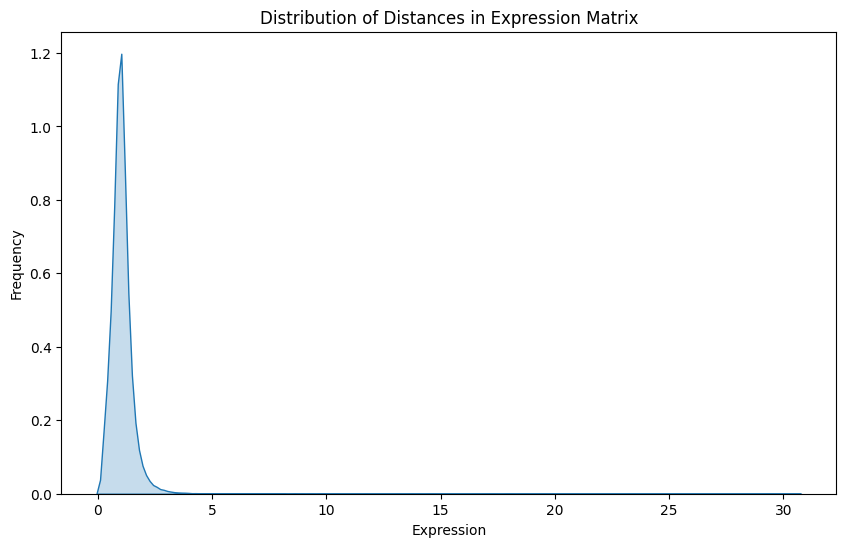

In [24]:
norm_test(fm_Gao)

0.5266582830143626


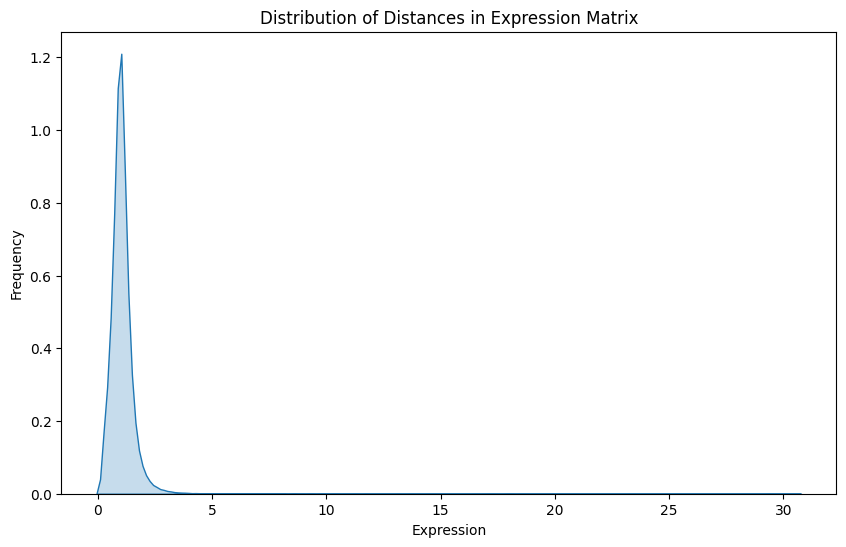

In [19]:
norm_test(fm_Gao)

In [17]:
import pandas as pd
for cohort in ['Jiang','Gao','xing']:
    data = pd.read_csv(f'/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12CohortsAgg_0.5nafilter_CoxSort/Reactome/{cohort}/feature_matrix.csv',index_col=0)
    print(cohort,f"samples size:{data.shape[0]}\n death rate:{data['death'].sum()/data.shape[0]}\n,num time bins:{data['OS time'].max()} ")



Jiang samples size:101
 death rate:0.1485148514851485
,num time bins:132.0 
Gao samples size:159
 death rate:0.3522012578616352
,num time bins:49.0 
xing samples size:152
 death rate:0.4605263157894737
,num time bins:81.0 


In [9]:
data


,ENSG00000187758,ENSG00000108064,ENSG00000124713,ENSG00000158710,ENSG00000074800,ENSG00000107566,ENSG00000113924,ENSG00000169359,ENSG00000172315,ENSG00000164104,...,ENSG00000090054,ENSG00000058262,ENSG00000126768,ENSG00000132842,ENSG00000180104,ENSG00000198380,ENSG00000185722,ENSG00000138107,OS time,death
X102T,1.727812,-0.106727,1.366863,1.823221,2.500381,-0.246124,1.563077,-0.248742,0.126215,0.734477,...,-0.690434,1.108615,-3.022390,-0.002014,-0.394784,0.504071,-0.464574,0.336936,29.0,0.0
X12004T,1.981819,0.106611,1.850998,1.698661,2.145936,0.965859,1.973822,-0.166776,0.187829,0.929716,...,-0.313772,0.993870,-0.496918,-0.524718,-0.951212,0.646300,0.009728,0.494906,63.0,0.0
X1210T,1.583631,-0.641573,0.543779,1.856172,2.017427,0.162456,1.941035,-0.076567,0.291522,0.915027,...,-0.620990,1.369120,-0.270903,-0.094206,-0.669508,0.931243,0.275008,0.421370,63.0,0.0
X12191T,1.553319,0.299542,1.180009,1.718175,2.175816,0.621155,2.126072,-0.660713,0.289435,0.673937,...,-0.439520,0.749395,-3.022390,0.016810,-0.533386,0.260595,-0.103979,0.698874,62.0,0.0
X1275T,2.080246,0.270501,0.904155,1.606359,1.990300,0.907794,2.127222,-0.125659,0.810648,0.768411,...,0.885608,1.040664,-0.269956,0.276359,-0.536481,0.071346,-0.112843,0.622575,62.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XH17T,1.014933,-3.022390,-1.185226,2.547110,2.724613,-0.006640,0.672357,-0.120082,0.158696,1.771418,...,0.329106,1.419040,-0.484976,0.360163,0.124381,1.104984,0.400302,0.884341,1.0,1.0
XL03T,1.124606,0.498645,0.408723,2.338671,2.481374,-0.195455,1.044615,-0.683362,-0.137572,2.187632,...,-0.675340,1.332217,-3.022390,-0.112804,-0.497607,0.759028,0.037774,0.558946,74.0,1.0
XL07T,1.051737,-0.018420,-1.331646,1.846069,2.222246,0.126758,0.679145,-0.535761,0.554536,1.960024,...,0.295891,1.392466,-0.701714,0.339346,0.123835,0.775329,0.376167,0.780813,108.0,0.0
XL09T,1.678559,0.256113,0.928210,2.135944,2.200546,0.371249,1.359617,-0.339005,0.369606,1.734978,...,0.266994,1.289988,-0.374875,0.287057,-0.624284,0.990508,0.649571,0.720764,104.0,0.0


In [1]:
import pandas as pd
clinic = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteomicsCohorts_clinic.csv',index_col=0)
clinic.head()

,OS time,death,RFS time,recurrence,BCLC stage,TNM stage,omics,cohort,ENSG00000213516,ENSG00000130402,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
G13082,7.4,1,3.8,1,A,IB,Protein,FZ,-0.895752,2.048098,...,-0.230078,0.656384,-0.057294,-0.706163,0.844387,1.782773,0.290391,-0.798579,-0.961604,-1.092316
G13092,19.0,1,15.4,1,B,IIIA,Protein,FZ,-0.615927,1.745620,...,NaN,0.713525,0.314971,-0.500891,0.606137,1.635512,0.046679,NaN,-0.541206,-0.662938
G13122,60.0,0,15.9,1,A,IB,Protein,FZ,-0.793476,1.436422,...,NaN,0.478639,-1.100018,-0.373413,0.935908,2.182356,-0.591657,NaN,-0.882975,0.208728
G13137,7.3,1,2.7,1,B,IIIA,Protein,FZ,-0.869422,1.407831,...,0.279023,0.528314,-0.517088,-0.150720,0.887987,1.136460,0.130425,-0.722675,-0.427647,NaN
G13162,60.0,0,14.5,1,A,II,Protein,FZ,-0.471138,1.403028,...,-0.342453,1.457994,-0.863085,-0.538429,0.229424,1.222436,0.123551,-1.122858,-0.619672,-1.049067


In [6]:
for cohort in ['Gao','Jiang','Xing']:
    df = pd.read_csv(f"/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/STRING/{cohort}/dataset.csv",index_col=0)
    print(cohort,df.shape[0])

Gao 159
Jiang 101
Xing 152


In [21]:
from DATA_preprocess import fil_min_nan_threshold
import os
for cohort in ['Gao','Jiang','Xing']:
    df = pd.read_csv(f"/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/STRING/{cohort}/dataset.csv",index_col=0)
    print(cohort,df.shape[0])
    fm=df.iloc[:,:-2]
    feature_matrix = fil_min_nan_threshold(fm.T,0.5)# gene x sample
    feature_matrix.shape
    fm = feature_matrix.T
    df_new = pd.concat([fm,df.iloc[:,-2:]],axis=1)
    save_path = f"/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/{cohort}/"
    os.makedirs(save_path,exist_ok=True)
    df_new.to_csv(save_path+"/dataset.csv")
df_new.head()

Gao 159
filt by nan_threshold: 0.5
------------------------------
after remove features with 0.5 NaN ,features:2700
Jiang 101
filt by nan_threshold: 0.5
------------------------------
after remove features with 0.5 NaN ,features:2615
Xing 152
filt by nan_threshold: 0.5
------------------------------
after remove features with 0.5 NaN ,features:2346


,ENSG00000066583,ENSG00000172164,ENSG00000163344,ENSG00000066926,ENSG00000152620,ENSG00000156110,ENSG00000108439,ENSG00000102743,ENSG00000139344,ENSG00000166123,...,ENSG00000135047,ENSG00000135932,ENSG00000164587,ENSG00000100296,ENSG00000072110,ENSG00000116030,ENSG00000119596,ENSG00000083312,OS time,death
1160T,-0.881059,-0.385412,0.307384,0.666586,0.861241,-0.385132,-0.039328,0.825897,-0.420956,-1.870162,...,0.280982,-0.952426,2.203507,-0.370035,2.279407,0.203719,-0.715503,0.292409,12.0,1
1175T,-0.367701,-0.078541,0.603304,1.054602,2.030314,-0.719639,0.886942,-0.131657,-0.338607,0.078791,...,-0.726266,-7.489326,1.984654,-0.438535,0.913251,0.186657,-0.853996,-0.450281,19.0,0
1185T,-0.587029,0.700382,0.710367,0.896839,2.023007,1.338274,0.999653,0.319054,-7.489326,0.897113,...,0.382289,-1.478699,1.935715,-7.489326,1.713584,0.468533,-7.489326,-0.344208,23.0,0
1186T,-0.292713,-0.741274,0.245416,0.652700,0.931535,-0.622245,0.112118,0.519547,-7.489326,-7.489326,...,-0.007514,-0.910264,2.193620,-0.142916,2.171507,0.402404,-0.721366,-0.159331,5.0,1
1188T,0.527307,-0.381771,0.068845,0.754522,1.345093,-0.618301,0.846536,1.046385,-0.023092,1.193588,...,0.196134,-0.765551,1.696469,-7.489326,1.888920,0.716382,-0.480305,0.158612,22.0,0


In [33]:
clinic.shape

(1386, 4420)

In [34]:
df_new = pd.DataFrame()
for cohort in ['Gao','Jiang','xing']:
    df = clinic.loc[(clinic['cohort']==cohort),:]
    df_new = pd.concat([df, df_new])
    print(clinic.loc[(clinic['cohort']==cohort),:].shape)
df_new

(159, 4420)
(101, 4420)
(152, 4420)


,OS time,death,RFS time,recurrence,BCLC stage,TNM stage,omics,cohort,ENSG00000213516,ENSG00000130402,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
1160T,36.87,1,7.30,1,A,IB,Protein,xing,0.153038,1.200955,...,-1.007958,1.181643,-0.689480,NaN,1.200104,1.421388,0.849430,NaN,-0.549795,-0.866772
1175T,55.87,0,55.87,0,0,IA,Protein,xing,-0.292845,0.402621,...,NaN,-1.939222,NaN,NaN,0.660060,1.716585,0.913302,NaN,-1.605163,-0.702191
1185T,69.93,0,15.07,1,B,IIIA,Protein,xing,-0.076820,0.754715,...,NaN,-0.854303,NaN,NaN,1.345776,1.846659,1.223602,NaN,NaN,-0.632927
1186T,15.67,1,5.97,1,C,IIIB,Protein,xing,-0.138901,0.998360,...,NaN,0.763807,-1.730383,NaN,1.189148,1.703247,0.713901,NaN,-0.223862,-0.896546
1188T,65.87,0,65.87,0,0,IA,Protein,xing,-0.253626,1.048010,...,-1.122119,0.094379,-1.197704,NaN,0.841290,1.373520,0.298263,-1.202950,-1.472546,-1.017789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,18.80,1,7.87,1,NaN,IIIB,Protein,Gao,1.189297,1.412366,...,1.071998,0.606214,1.451467,1.294584,2.104169,0.815095,0.586051,0.602796,1.074939,2.095379
T1031,32.77,0,32.77,0,NaN,IB,Protein,Gao,0.987709,0.868255,...,1.054798,1.005816,1.059553,0.873412,0.995472,1.057507,1.009892,1.360837,1.056333,0.641038
T1041,32.43,0,6.33,1,NaN,IIIB,Protein,Gao,1.607022,0.831138,...,1.069320,0.463674,1.456859,1.795438,1.453885,1.971948,1.837950,0.578705,0.987275,1.547327
T1043,32.60,0,32.60,0,NaN,IB,Protein,Gao,0.750455,0.953456,...,1.277719,0.850404,0.963769,1.024819,0.949214,0.646439,1.731029,1.249777,1.207774,1.111839


In [36]:
df = clinic.loc[(clinic['cohort']=='Gao'),:]

In [38]:
fm_Gao=df.iloc[:,8:]

In [43]:
fm_Gao

,ENSG00000213516,ENSG00000130402,ENSG00000185567,ENSG00000099968,ENSG00000072786,ENSG00000142875,ENSG00000166479,ENSG00000132670,ENSG00000186687,ENSG00000141556,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
T112,1.377616,1.673161,0.382488,0.765353,0.546627,0.733041,0.732892,1.034171,1.527642,0.842673,...,1.368484,0.651949,0.889941,1.485412,1.260029,0.743500,0.978846,0.288144,0.601312,1.549897
T113,1.225721,0.728060,0.644195,1.091575,0.828572,0.737708,1.095735,0.705898,1.002206,0.943432,...,1.086564,0.887418,1.386828,1.195749,1.039594,1.043099,0.951911,0.569231,0.945904,1.075335
T123,2.052832,0.748729,0.287098,0.538301,0.635609,1.173098,0.583281,0.793541,0.999973,1.232461,...,0.862378,0.570819,1.151412,1.561222,1.415927,0.553023,0.628763,0.240948,0.528750,1.238439
T125,0.938790,0.796036,1.147903,0.527129,1.107144,1.432931,1.868326,1.032090,0.633345,1.617000,...,1.231191,0.654282,1.044082,0.798813,0.869589,0.572108,0.380856,0.538978,1.182271,0.627997
T127,1.097016,1.073589,0.271084,0.931036,0.576668,1.237394,0.838532,0.909771,0.848413,1.125027,...,1.023080,0.678391,1.147189,1.197282,0.714713,0.892957,0.945287,0.438410,0.756769,1.369995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,1.189297,1.412366,1.212758,0.925490,0.736535,1.810170,0.909577,0.961198,2.406020,2.261097,...,1.071998,0.606214,1.451467,1.294584,2.104169,0.815095,0.586051,0.602796,1.074939,2.095379
T1031,0.987709,0.868255,0.497943,0.886066,1.421333,0.604557,1.103073,0.951239,0.557769,1.161581,...,1.054798,1.005816,1.059553,0.873412,0.995472,1.057507,1.009892,1.360837,1.056333,0.641038
T1041,1.607022,0.831138,1.018463,1.756116,0.824629,0.996452,0.799342,1.009492,1.761308,0.991887,...,1.069320,0.463674,1.456859,1.795438,1.453885,1.971948,1.837950,0.578705,0.987275,1.547327
T1043,0.750455,0.953456,0.409269,1.109833,1.067155,0.676015,0.901304,1.022031,0.796573,2.039354,...,1.277719,0.850404,0.963769,1.024819,0.949214,0.646439,1.731029,1.249777,1.207774,1.111839


In [44]:
# 正态分布检验
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
def norm_test(df):
    '''
    gene*sample
    '''
    data = np.matrix(df).ravel().tolist()
    data = np.random.choice(np.squeeze(data), size=10000000)
    print(data[~np.isnan(data)].std())
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data, fill=True)
    plt.xlabel('Expression')
    plt.ylabel('Frequency')
    plt.title('Distribution of Distances in Gene Co-expression Matrix')
    plt.show()
    # plt.savefig(f'Expression_distribution_{}.pdf')

In [46]:
df_Gao = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12CohortsAgg_0.5nafilter_CoxSort/Reactome/Gao/feature_matrix.csv',index_col=0)
df_Gao.head()

,ENSG00000160551,ENSG00000128595,ENSG00000184575,ENSG00000157227,ENSG00000144524,ENSG00000167325,ENSG00000149257,ENSG00000125107,ENSG00000130150,ENSG00000183735,...,ENSG00000165637,ENSG00000105829,ENSG00000157131,ENSG00000168298,ENSG00000179604,ENSG00000109270,ENSG00000079385,ENSG00000167508,OS time,death
T112,1.039772,0.474535,0.863578,0.675402,0.870426,0.743292,0.659184,1.297409,0.831184,1.041891,...,0.919767,0.904164,0.839840,1.646632,0.998072,0.930356,2.258414,1.050736,47.0,0.0
T113,1.051567,1.022914,1.177428,1.176816,1.138951,0.980958,1.205429,1.140426,0.840298,0.907331,...,1.090101,1.571654,0.778111,0.704939,0.607740,0.985958,1.576585,1.117672,49.0,0.0
T123,1.043573,1.495125,2.163705,0.887035,0.724539,0.771483,0.635684,1.217838,1.805383,1.198813,...,0.896105,1.707779,0.699484,1.028022,1.399386,0.801160,0.744447,0.572151,15.0,1.0
T125,1.320987,1.361181,1.882487,2.459620,1.190677,1.487225,1.328362,1.176488,1.438000,1.597960,...,1.213897,0.923885,1.360716,0.674740,0.790210,1.081482,1.073075,0.420253,9.0,1.0
T127,1.304523,0.773563,1.083541,0.679304,0.825121,1.501785,0.921711,1.032338,1.101365,0.968574,...,1.028166,1.050106,0.567409,0.777244,0.785137,0.976299,0.895039,0.584839,48.0,0.0


0.5288131707821698


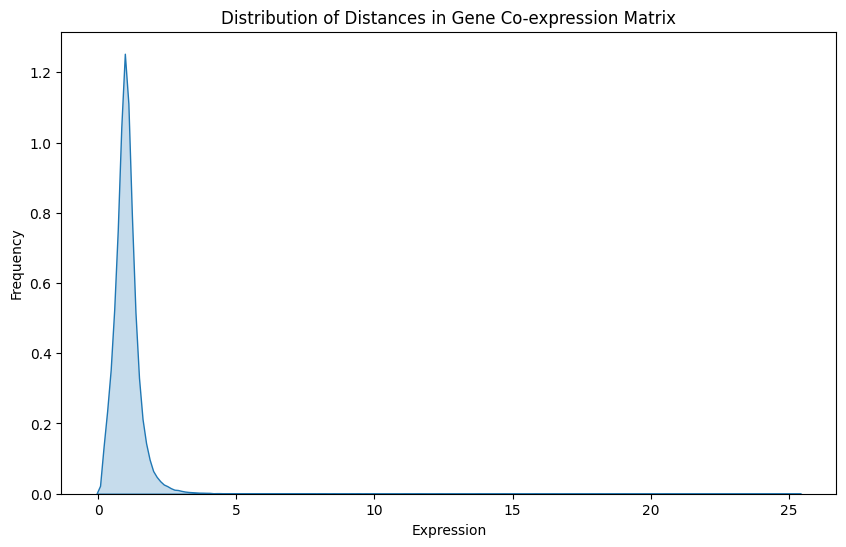

In [47]:
norm_test(df_Gao.iloc[:,:-2].T)

0.5206456332571935


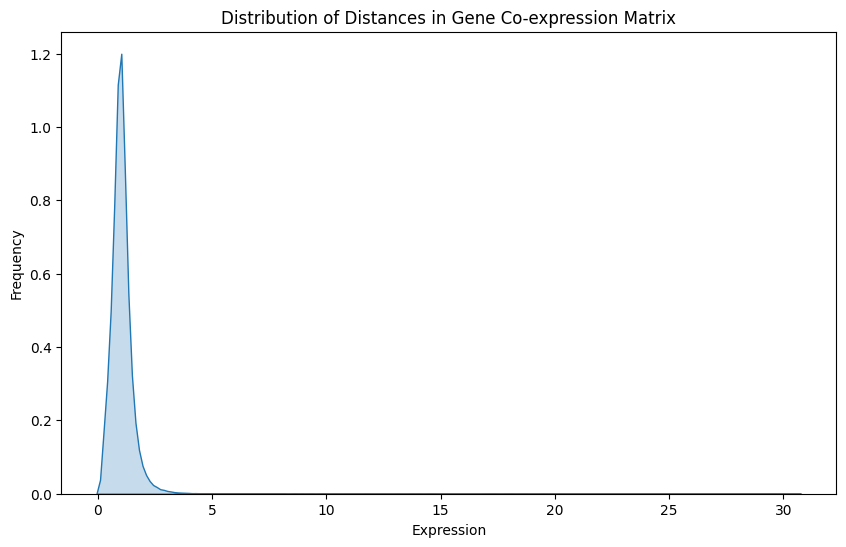

In [45]:
norm_test(fm_Gao.T)

In [48]:
# 对Gao进行log2处理
fm_log2 = np.log2(fm_Gao+1)
fm_log2

,ENSG00000213516,ENSG00000130402,ENSG00000185567,ENSG00000099968,ENSG00000072786,ENSG00000142875,ENSG00000166479,ENSG00000132670,ENSG00000186687,ENSG00000141556,...,ENSG00000169397,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
T112,1.249516,1.418547,0.467267,0.819957,0.629125,0.793306,0.793181,1.024441,1.337792,0.881800,...,1.243964,0.724169,0.918341,1.313485,1.176342,0.801987,0.984659,0.365294,0.679254,1.350439
T113,1.154273,0.789154,0.717382,1.064590,0.870718,0.797186,1.067456,0.770532,1.001590,0.958606,...,1.061129,0.916414,1.255094,1.134713,1.028282,1.030759,0.964887,0.650058,0.960440,1.053345
T123,1.610148,0.806307,0.364122,0.621338,0.709828,1.119753,0.662917,0.842811,0.999980,1.158635,...,0.897146,0.651517,1.105284,1.356832,1.272577,0.635079,0.703776,0.311442,0.612352,1.162493
T125,0.955157,0.844816,1.102929,0.610822,1.075289,1.282696,1.520209,1.022964,0.707830,1.387914,...,1.157814,0.726205,1.031453,0.847046,0.902721,0.652700,0.465563,0.621972,1.125830,0.703098
T127,1.068338,1.052130,0.346059,0.949375,0.656879,1.161819,0.878554,0.933400,0.886287,1.087481,...,1.016553,0.747079,1.102449,1.135720,0.777967,0.920641,0.959983,0.524475,0.812924,1.244884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,1.130468,1.270449,1.145846,0.945226,0.796211,1.490658,0.933253,0.971735,1.768087,1.705358,...,1.051022,0.683664,1.293645,1.198233,1.634207,0.860045,0.665439,0.680591,1.053069,1.630116
T1031,0.991106,0.901691,0.582983,0.915380,1.275801,0.682175,1.072499,0.964390,0.639481,1.112087,...,1.038996,1.004189,1.042331,0.905668,0.996730,1.040898,1.007118,1.239298,1.040074,0.714609
T1041,1.382403,0.872741,1.013257,1.462637,0.867604,0.997438,0.847469,1.006831,1.465352,0.994136,...,1.049156,0.549594,1.296815,1.483074,1.295068,1.571409,1.504849,0.658742,0.990791,1.348984
T1043,0.807730,0.966029,0.494947,1.077129,1.047647,0.745035,0.926989,1.015805,0.845248,1.603765,...,1.187590,0.887840,0.973625,1.017793,0.962893,0.719349,1.449444,1.169782,1.142593,1.078500


0.3109233067665501


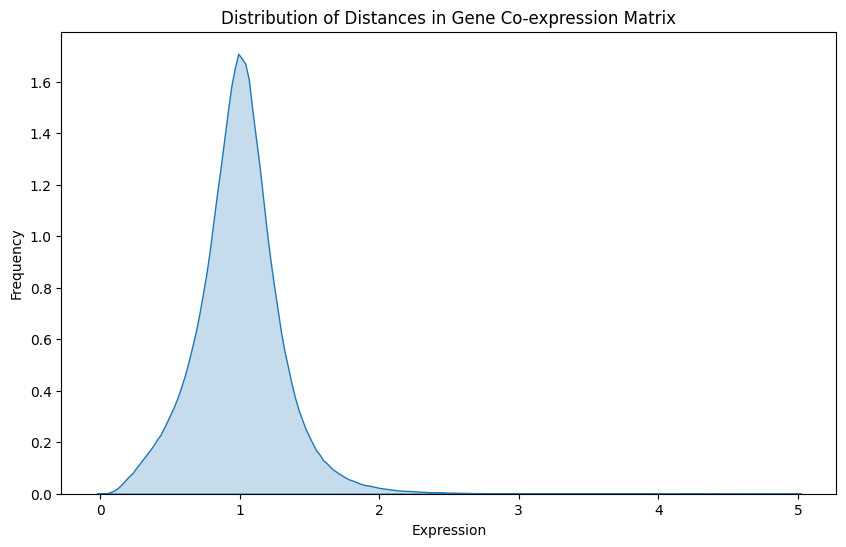

In [49]:
norm_test(fm_lobg2.T)


In [51]:
# 数据标准化(MEAN=0 NORM FOR DEEP LEARNING) z-score
from scipy.stats import zscore 
fm_log_z = zscore(fm_log2,axis=1)# 每一个基因在所有样本上的均值接近零，方差接近一 
                    

In [58]:
fm_log_z.mean(axis=1)

T112    -4.957956e-15
T113     5.252673e-16
T123     4.482161e-16
T125     2.403210e-15
T127    -7.384694e-15
             ...     
T1027    2.389446e-15
T1031    3.467836e-15
T1041   -1.046715e-14
T1043   -6.279976e-15
T1045    4.553701e-15
Length: 159, dtype: float64

0.9998506245822599


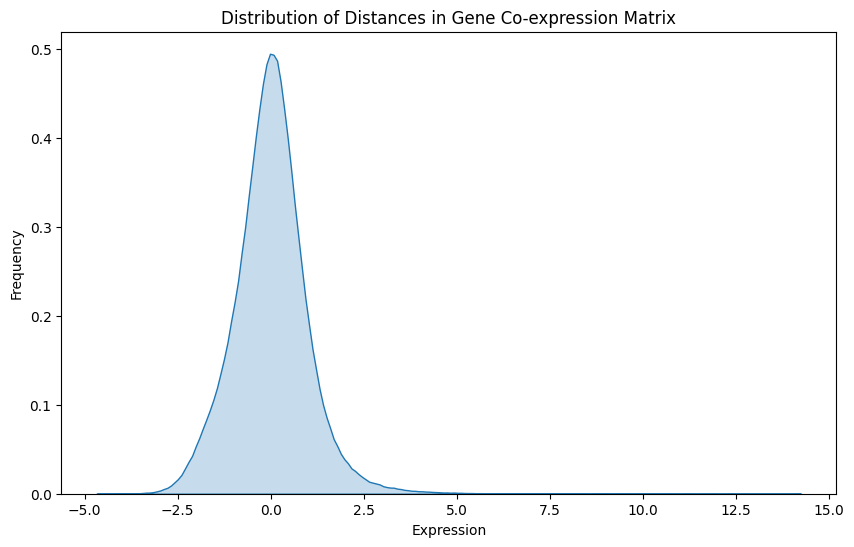

In [59]:
norm_test(fm_log_z.T)


In [75]:
df_gene = pd.read_csv('/Backup/home/chenyupeng/DATA/PRO/HCC/0.8nafilter_CoxSort/ALL/Gao/genes_list.csv',index_col=0)    
fm_new = fm_log_z.loc[:,df_gene.index]
df_Gao_new = pd.concat([fm_new,df_Gao.iloc[:,-2:]],axis=1)
df_Gao_new

,ENSG00000160551,ENSG00000122965,ENSG00000128595,ENSG00000205531,ENSG00000184575,ENSG00000136261,ENSG00000198925,ENSG00000164916,ENSG00000144524,ENSG00000100226,...,ENSG00000104611,ENSG00000120708,ENSG00000109270,ENSG00000186517,ENSG00000140694,ENSG00000065000,ENSG00000135047,ENSG00000127838,OS time,death
T112,0.157744,0.470525,-1.500376,-0.034273,-0.303880,-0.487950,-0.303919,-0.308389,-0.285135,-0.000840,...,-0.335641,-1.246607,-0.123980,-1.025887,-0.068172,-0.394154,-1.408451,-0.719258,47.0,0.0
T113,0.157921,0.175132,0.079379,-0.270326,0.490411,0.090477,-0.023850,-0.120614,0.390850,-0.085063,...,1.175348,-1.729338,-0.023584,-0.350072,0.829729,0.574578,-0.662711,0.708141,49.0,0.0
T123,0.154676,1.159354,0.979754,-0.087116,1.960911,0.098358,1.111931,-0.065139,-0.546832,-0.683037,...,1.370383,-1.898318,-0.367172,-1.130085,0.777479,-0.547690,-1.363486,-0.011502,15.0,1.0
T125,0.698788,0.101750,0.768910,0.531141,1.583644,1.868948,0.962636,0.265161,0.462803,-0.279913,...,0.124456,-0.520753,0.253983,0.329547,-0.470880,0.172030,0.921880,0.096404,9.0,1.0
T127,0.837735,0.586433,-0.611586,0.839648,0.279858,-0.361776,1.323978,-0.446605,-0.452998,-0.505344,...,-0.703234,-1.168466,-0.012587,-1.189462,1.023459,-0.335974,-1.400502,1.105850,48.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,-0.246108,-0.295028,0.286157,1.446838,1.214755,0.048076,0.224073,-0.444871,1.205051,0.365878,...,0.530553,-0.714851,0.095925,-1.043709,-0.319836,-1.812193,-0.016923,0.537551,18.0,1.0
T1031,-1.100569,0.387013,-0.712480,0.466193,-0.223260,0.799861,1.519565,0.722318,0.759812,0.670573,...,0.737211,0.720453,0.173064,1.513116,0.175051,0.758085,0.155886,-0.618319,32.0,0.0
T1041,-0.924964,0.228022,-0.483014,-0.487497,-0.557958,0.805876,-0.454112,-0.066308,-0.625969,0.327600,...,-0.245632,-0.766993,0.538403,-0.834271,0.450140,0.121768,-0.582283,-0.562347,32.0,0.0
T1043,-0.451124,-0.808718,-0.336579,0.247005,-0.130640,0.079870,-0.527096,-0.024287,0.235412,0.423358,...,1.008514,-1.139956,-0.436534,0.511376,-0.451016,0.162255,0.220658,0.628301,32.0,0.0


In [76]:
df_Gao_new.to_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/ALL/Gao/dataset.csv")
df_Gao_new.to_csv("/Backup/home/chenyupeng/DATA/PRO/HCC/0.8nafilter_CoxSort/ALL/Gao/dataset.csv")

In [72]:
gene_STRING = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/STRING/Gao/genes_list.csv',index_col=0)
gene_STRING.head()

,cox_p_value
ENSG00000160551,4.939223e-08
ENSG00000122965,1.414312e-07
ENSG00000128595,2.560602e-07
ENSG00000184575,4.987542e-07
ENSG00000164916,1.225240e-06


In [77]:
fm_STRING = fm_log_z.loc[:,gene_STRING.index]
df_Gao_STRING = pd.concat([fm_STRING,df_Gao.iloc[:,-2:]],axis=1)
df_Gao_STRING

,ENSG00000160551,ENSG00000122965,ENSG00000128595,ENSG00000184575,ENSG00000164916,ENSG00000004487,ENSG00000125107,ENSG00000067225,ENSG00000130150,ENSG00000170275,...,ENSG00000103485,ENSG00000104611,ENSG00000120708,ENSG00000109270,ENSG00000140694,ENSG00000065000,ENSG00000135047,ENSG00000127838,OS time,death
T112,0.157744,0.470525,-1.500376,-0.303880,-0.308389,0.563081,0.765529,-1.864993,-0.393482,0.063212,...,-1.299502,-0.335641,-1.246607,-0.123980,-0.068172,-0.394154,-1.408451,-0.719258,47.0,0.0
T113,0.157921,0.175132,0.079379,0.490411,-0.120614,-0.033078,0.394699,-1.239061,-0.448961,0.198729,...,-0.270081,1.175348,-1.729338,-0.023584,0.829729,0.574578,-0.662711,0.708141,49.0,0.0
T123,0.154676,1.159354,0.979754,1.960911,-0.065139,0.371752,0.492880,-0.968004,1.464128,1.545840,...,0.577275,1.370383,-1.898318,-0.367172,0.777479,-0.547690,-1.363486,-0.011502,15.0,1.0
T125,0.698788,0.101750,0.768910,1.583644,0.265161,0.662225,0.436265,3.195897,0.899665,3.234484,...,-0.681661,0.124456,-0.520753,0.253983,-0.470880,0.172030,0.921880,0.096404,9.0,1.0
T127,0.837735,0.586433,-0.611586,0.279858,-0.446605,0.322409,0.142156,-1.408180,0.326999,-0.546791,...,0.888573,-0.703234,-1.168466,-0.012587,1.023459,-0.335974,-1.400502,1.105850,48.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,-0.246108,-0.295028,0.286157,1.214755,-0.444871,-0.317018,0.358338,1.637340,0.856399,-0.304115,...,1.527765,0.530553,-0.714851,0.095925,-0.319836,-1.812193,-0.016923,0.537551,18.0,1.0
T1031,-1.100569,0.387013,-0.712480,-0.223260,0.722318,0.735202,0.252278,-0.220705,-0.243155,-0.792654,...,-1.714054,0.737211,0.720453,0.173064,0.175051,0.758085,0.155886,-0.618319,32.0,0.0
T1041,-0.924964,0.228022,-0.483014,-0.557958,-0.066308,-0.281900,0.122240,-1.484079,-0.537602,-0.242197,...,-0.977034,-0.245632,-0.766993,0.538403,0.450140,0.121768,-0.582283,-0.562347,32.0,0.0
T1043,-0.451124,-0.808718,-0.336579,-0.130640,-0.024287,-0.255612,-0.043747,0.367249,0.425666,0.156113,...,-1.466311,1.008514,-1.139956,-0.436534,-0.451016,0.162255,0.220658,0.628301,32.0,0.0


In [78]:
df_Gao_STRING.to_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/STRING/Gao/dataset.csv')
df_Gao_STRING.to_csv('/Backup/home/chenyupeng/DATA/PRO/HCC/0.8nafilter_CoxSort/STRING/Gao/dataset.csv')


In [82]:
df.sort_index(axis=1)

,BCLC stage,ENSG00000000003,ENSG00000000419,ENSG00000001036,ENSG00000001084,ENSG00000001497,ENSG00000001561,ENSG00000001630,ENSG00000002330,ENSG00000002549,...,ENSG00000284194,ENSG00000288702,ENSG00000291237,OS time,RFS time,TNM stage,cohort,death,omics,recurrence
T112,NaN,1.198758,1.913074,1.080417,0.849269,1.299092,0.432441,1.074885,1.050188,0.693670,...,1.241989,1.261063,1.328212,47.90,11.47,IB,Gao,0,Protein,1
T113,NaN,0.891156,1.368746,1.088832,0.934213,1.454255,0.719305,0.696785,0.716168,2.922364,...,0.925157,1.093330,4.029038,49.60,11.40,IIIA,Gao,0,Protein,1
T123,NaN,0.896190,1.192989,1.382117,0.787851,2.058892,0.535650,1.518604,1.608345,0.609781,...,1.001926,1.702197,0.434560,15.67,7.50,IB,Gao,1,Protein,1
T125,NaN,1.059846,1.151598,2.252626,0.372147,1.300385,1.371052,0.333443,1.228152,0.485393,...,0.527136,0.446932,0.852115,9.30,9.30,IB,Gao,1,Protein,0
T127,NaN,0.690888,1.525198,0.865751,1.847644,1.343017,0.543429,1.013503,1.405542,1.087248,...,1.088567,2.511609,0.350141,48.30,48.30,IB,Gao,0,Protein,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,NaN,1.005809,1.091526,0.584614,0.733908,0.783904,1.097985,2.753923,1.387254,0.893541,...,1.054745,1.179030,0.406923,18.80,7.87,IIIB,Gao,1,Protein,1
T1031,NaN,1.174065,1.055392,0.748188,0.675528,1.478815,1.254193,1.211435,0.975393,0.862113,...,1.062041,0.402203,0.747964,32.77,32.77,IB,Gao,0,Protein,0
T1041,NaN,0.926608,1.018775,0.542127,1.194502,0.926395,0.978184,1.289873,2.061340,0.862238,...,1.278884,2.904196,0.923047,32.43,6.33,IIIB,Gao,0,Protein,1
T1043,NaN,1.733132,1.294599,0.864628,0.835499,1.317655,1.463886,1.816481,0.399365,1.886239,...,1.289951,1.496762,1.584161,32.60,32.60,IB,Gao,0,Protein,0


## HCC Proteomic Data Concat

In [83]:
import pandas as pd
df_list = []
for cohort in ['Gao','Jiang','Xing']:
    df_list.append(pd.read_csv(f'/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.8nafilter_CoxSort/ALL/{cohort}/dataset.csv',index_col=0).sort_index(axis=1))
    df = pd.concat(df_list,axis=0)
df

,ENSG00000000003,ENSG00000000419,ENSG00000001036,ENSG00000001084,ENSG00000001497,ENSG00000001561,ENSG00000001630,ENSG00000002330,ENSG00000002549,ENSG00000002822,...,ENSG00000277972,ENSG00000278053,ENSG00000278535,ENSG00000278619,ENSG00000278845,ENSG00000284194,ENSG00000288702,ENSG00000291237,OS time,death
T112,0.541262,1.978744,0.258563,-0.343264,0.769270,-1.648373,0.244958,0.183771,-0.792381,-0.216615,...,-0.139318,0.860765,-0.407826,-0.136154,0.019744,0.640754,0.684043,0.833586,47.0,0.0
T113,-0.296729,0.960703,0.258443,-0.171014,1.158736,-0.828735,-0.902365,-0.838936,3.777057,-0.514282,...,-0.900650,0.873714,-1.153578,0.389553,0.362337,-0.197223,0.270455,5.164949,49.0,0.0
T123,-0.154679,0.446313,0.788200,-0.397825,1.821672,-1.026266,1.018461,1.163157,-0.831425,-0.196319,...,-0.930238,0.528176,-1.611115,-1.047735,0.871114,0.069581,1.309251,-1.307695,15.0,1.0
T125,0.211309,0.389291,2.077035,-1.447856,0.662374,0.785948,-1.564712,0.532077,-1.123979,-0.516537,...,-1.336987,0.356474,-0.863132,0.839011,-0.451704,-1.010791,-1.231122,-0.222838,9.0,1.0
T127,-0.875772,1.343818,-0.331149,2.008880,0.929415,-1.380758,0.090627,1.075163,0.289695,0.121734,...,0.858517,1.504262,-0.568745,0.456057,1.442586,0.293192,3.168757,-2.121225,48.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452T,-0.120064,0.589372,-0.463780,-0.534671,-7.489326,-7.489326,-0.062959,0.915381,1.325766,-7.489326,...,0.042588,-7.489326,-7.489326,-7.489326,-0.538186,-0.099790,1.109845,2.369381,5.0,0.0
2453T,-0.131222,-0.059703,-1.016802,-0.131913,-7.489326,-7.489326,-0.676445,1.147264,2.067194,-1.248859,...,-0.370507,-7.489326,-0.468808,-1.365637,-0.297873,-0.266531,0.378870,1.845051,6.0,0.0
2458T,-0.135764,1.014340,0.527404,-0.762724,-0.897419,-1.993408,0.565300,1.243256,1.026006,-1.160495,...,0.461316,-7.489326,-7.489326,-7.489326,-0.355628,-0.125777,0.026908,1.444140,6.0,0.0
2467T,-0.022510,0.774538,-0.737713,0.372315,-0.700252,-2.454017,-0.448920,0.904023,1.773312,-1.123341,...,-0.330057,-1.716350,-7.489326,-1.316802,-0.006305,0.258739,0.468732,2.801628,6.0,0.0


Gao
1.0002327927811603


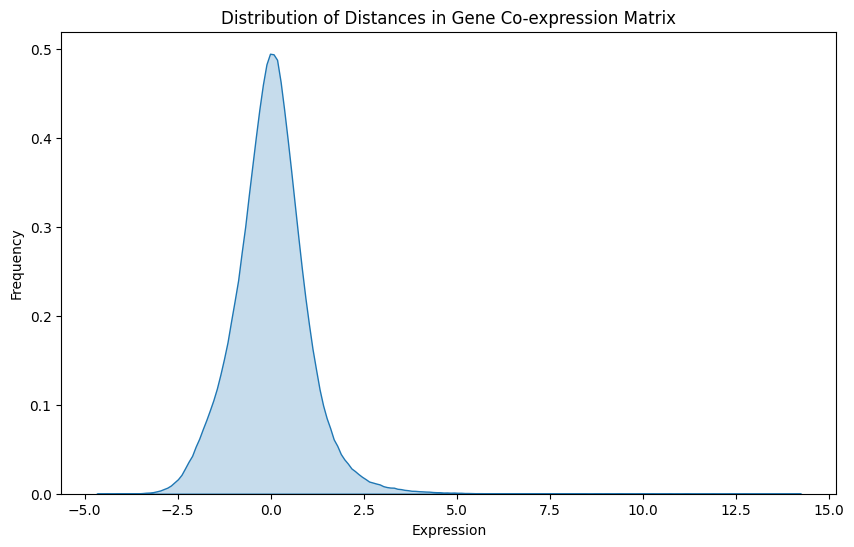

Jiang
1.283825947929532


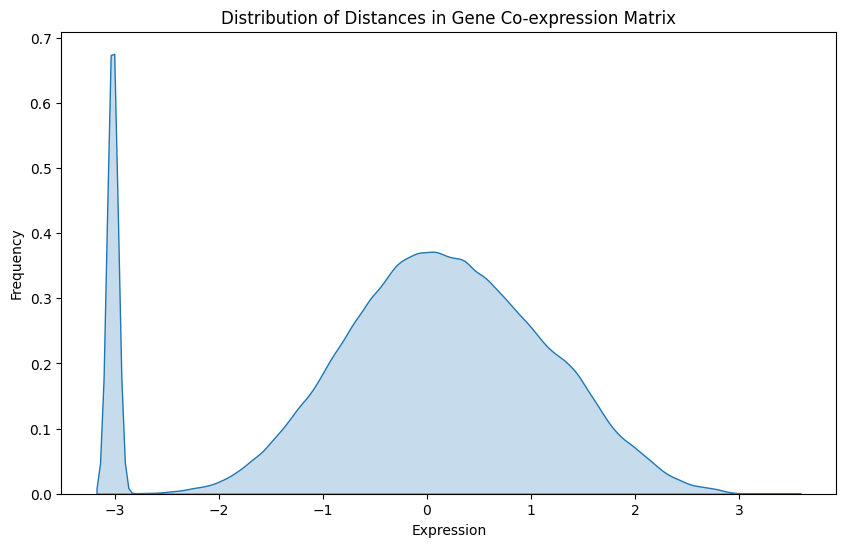

Xing
3.056201840186215


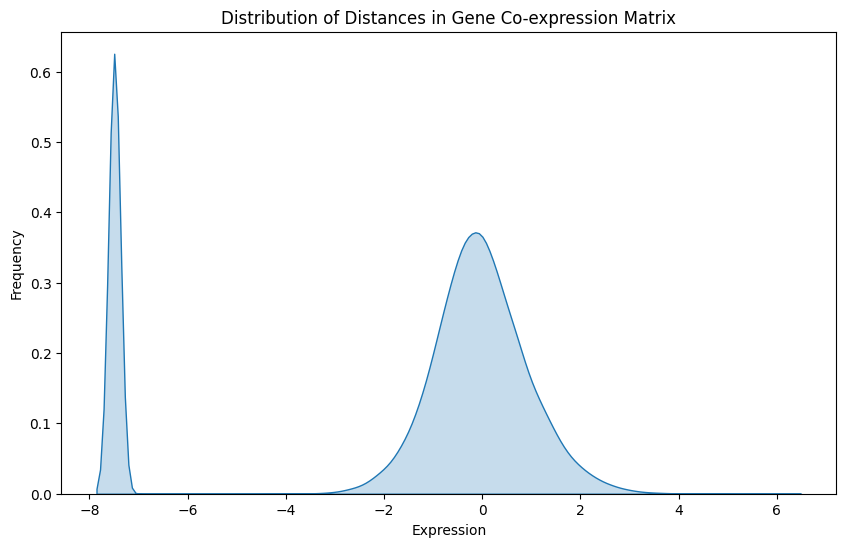

In [87]:
for i,cohort in enumerate(['Gao','Jiang','Xing']):
    print(cohort)
    fm = df_list[i].iloc[:,:-2]
    norm_test(fm)

filt by nan_threshold: 0.5
------------------------------
after remove features with 0.5 NaN ,features:3801
2.5890271008827543


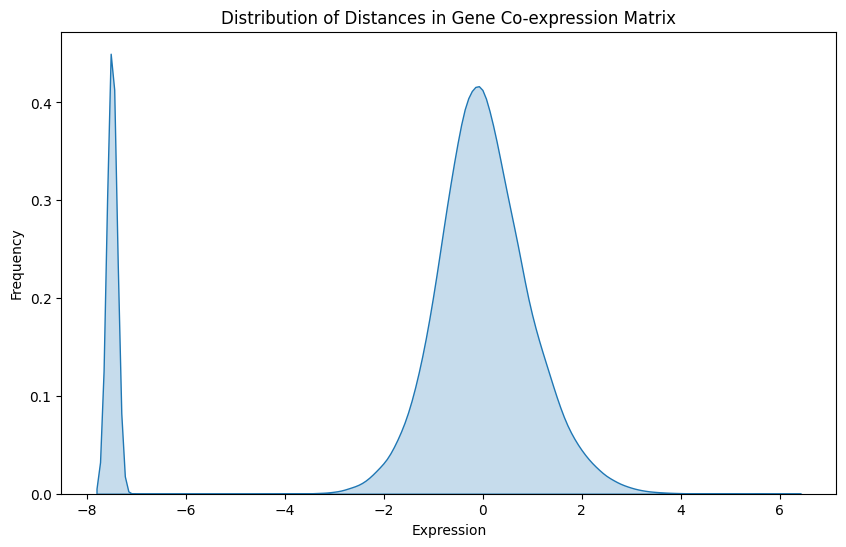

In [ ]:
norm_test(fil_min_nan_threshold(fm.T,0.5).T)

1.0001434613668032


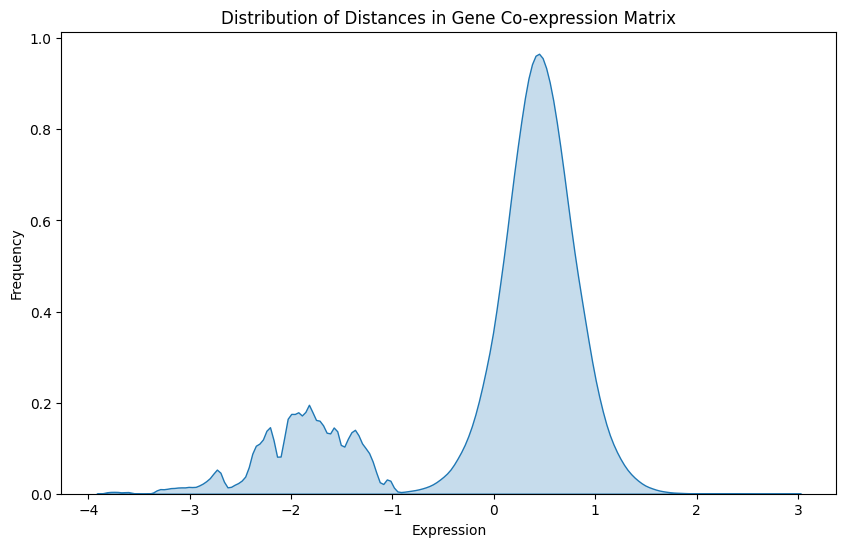

In [95]:
norm_test(zscore(fm,axis=1).T)

In [94]:
zscore(fm,axis=1).mean(axis=1)

1160T   -2.280889e-15
1175T    1.066826e-14
1185T    9.369004e-15
1186T   -1.086016e-15
1188T   -3.125711e-15
             ...     
2452T    2.626588e-15
2453T    3.169068e-15
2458T   -3.371686e-16
2467T   -2.354518e-15
2511T   -2.794783e-15
Length: 152, dtype: float64

In [ ]:
# 数据标准化(MEAN=0 NORM FOR DEEP LEARNING) z-score
from scipy.stats import zscore 
fm_log_z = zscore(fm_log2,axis=1)# 每一个基因在所有样本上的均值接近零，方差接近一 



In [86]:
df.mean(axis=1)



T112     0.010648
T113     0.011101
T123     0.003625
T125     0.002266
T127     0.010874
           ...   
2452T   -1.528193
2453T   -1.660890
2458T   -1.197100
2467T   -1.056429
2511T   -0.801308
Length: 412, dtype: float64

In [1]:
import pandas as pd
clinic = pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12Cohorts_clinic.csv",index_col=0)   
df_Gao = clinic.loc[clinic['cohort'] == 'Gao']
df_Gao

/tmp/ipykernel_4130542/2334091082.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  clinic = pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12Cohorts_clinic.csv",index_col=0)


,OS time,death,RFS time,recurrence,BCLC stage,TNM stage,omics,cohort,ENSG00000186063,ENSG00000100600,...,ENSG00000067829,ENSG00000090263,ENSG00000176919,ENSG00000125450,ENSG00000213619,ENSG00000247596,ENSG00000111816,ENSG00000138794,ENSG00000204256,ENSG00000033050
T112,47.90,0.0,11.47,1.0,NaN,IB,Protein,Gao,1.216548,0.850242,...,0.926492,0.999459,0.918306,1.224470,1.049460,1.694881,0.884108,0.776891,1.430335,0.722651
T113,49.60,0.0,11.40,1.0,NaN,IIIA,Protein,Gao,0.964675,1.355742,...,1.080294,0.904786,1.240024,1.004941,1.043337,0.965473,1.115507,1.293198,0.922858,1.269661
T123,15.67,1.0,7.50,1.0,NaN,IB,Protein,Gao,1.031395,0.431051,...,0.930756,1.391701,0.641146,1.628861,0.710856,1.190745,2.146358,0.920407,1.962898,1.450308
T125,9.30,1.0,9.30,0.0,NaN,IB,Protein,Gao,1.045569,0.705840,...,0.771539,0.768865,2.044829,1.179988,0.709480,0.951666,0.576363,1.619234,0.877776,1.424895
T127,48.30,0.0,48.30,0.0,NaN,IB,Protein,Gao,0.961146,0.575435,...,1.447876,1.425211,0.650022,1.210211,1.026082,1.193849,0.863893,0.782726,1.478396,0.898545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,18.80,1.0,7.87,1.0,NaN,IIIB,Protein,Gao,1.300138,1.887897,...,2.087037,0.642112,0.691278,0.912635,0.817039,0.596591,0.740820,0.742433,1.293943,3.109131
T1031,32.77,0.0,32.77,0.0,NaN,IB,Protein,Gao,1.379232,1.062337,...,0.965071,1.253000,0.561158,1.349999,1.088999,1.365608,0.784567,0.991300,1.027673,0.854065
T1041,32.43,0.0,6.33,1.0,NaN,IIIB,Protein,Gao,1.082060,0.961781,...,1.280661,2.049358,0.841956,1.363105,1.562965,1.644706,0.389680,0.929778,1.768887,1.021587
T1043,32.60,0.0,32.60,0.0,NaN,IB,Protein,Gao,1.407521,1.326078,...,1.376005,0.866780,0.887305,1.127152,1.588861,1.064767,1.228927,0.778268,0.916022,0.992810


In [9]:
fm_Gao.isna().sum().sum()

0

In [6]:
fm_Gao = df_Gao.iloc[:,8:]

0.5270613179604492


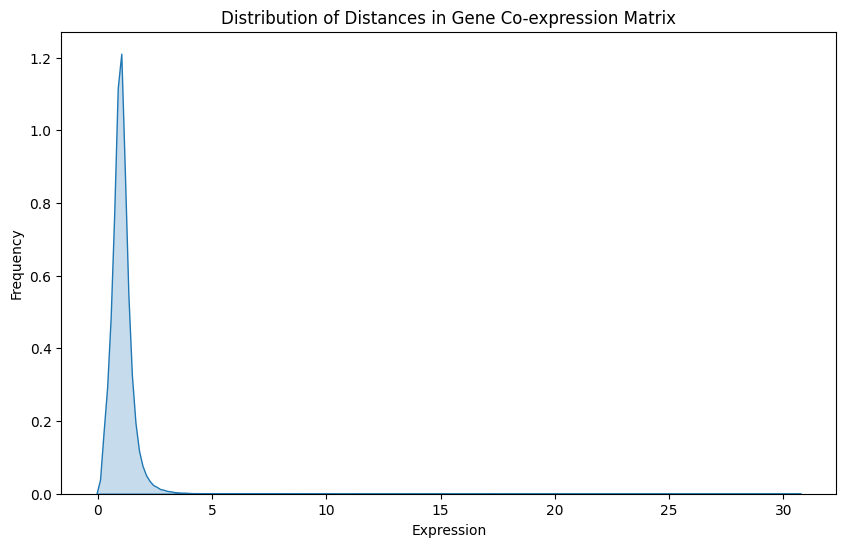

In [7]:
from DATA_preprocess import norm_test
norm_test(fm_Gao)

In [ ]:
import pandas as pd
clinic = pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12Cohorts_clinic.csv",index_col=0)   
df_Gao = clinic.loc[clinic['cohort'] == 'Gao']

In [13]:
df_Gao_Original = pd.read_excel("/Backup/home/chenyupeng/DATA/mmc1.xlsx",index_col=0,sheet_name='3. 6,478 proteins at gene level')
df_Gao_Original.head()

,T112,T113,T123,T125,T127,T131,T135,T137,T141,T145,...,N983,N1013,N1015,N1021,N1025,N1027,N1031,N1041,N1043,N1045
Sample ID Protein,,,,,,,,,,,,,,,,,,,,,
IGHV3-49,0.589275,-0.042816,-0.062434,1.232591,-0.594934,-0.677810,0.263535,0.241267,0.473258,0.753029,...,-0.088868,-0.612395,-0.236052,-0.148172,-1.047293,-0.623192,-0.419039,-0.288235,0.410538,-0.231669
IGHV6-1,-0.431827,-0.614849,-1.043460,0.426004,-0.599542,-0.322996,0.595639,0.171741,-0.347393,0.891794,...,-1.125284,-0.889479,0.980734,0.734249,0.039690,0.298280,-0.297226,1.379007,-0.861912,-1.047585
IGHV3-72,-0.742205,-1.096484,-1.462146,0.020010,-0.957436,0.024966,-0.091143,0.691294,-0.602503,-0.318260,...,-0.518032,-0.813562,-0.174075,-0.359965,-0.117872,0.149684,-0.594820,0.347083,-0.302549,-0.401524
IGHV1-3,-0.476795,-0.691952,-0.894658,0.244307,-0.803558,-0.428105,-0.365339,-0.043442,0.146965,-0.374111,...,-0.811729,-1.084211,0.123803,0.300513,-0.125644,-0.083313,-0.624765,0.020907,-0.747530,-1.027132
IGHV4-28,-1.092085,-1.251609,-1.855076,0.074542,-1.527752,-0.212931,-0.281641,0.219844,-0.415336,0.952804,...,0.037913,-0.311629,-0.133707,0.635025,-0.588605,0.267389,-0.471834,0.084909,0.088689,-0.346842


0.5572494522682485


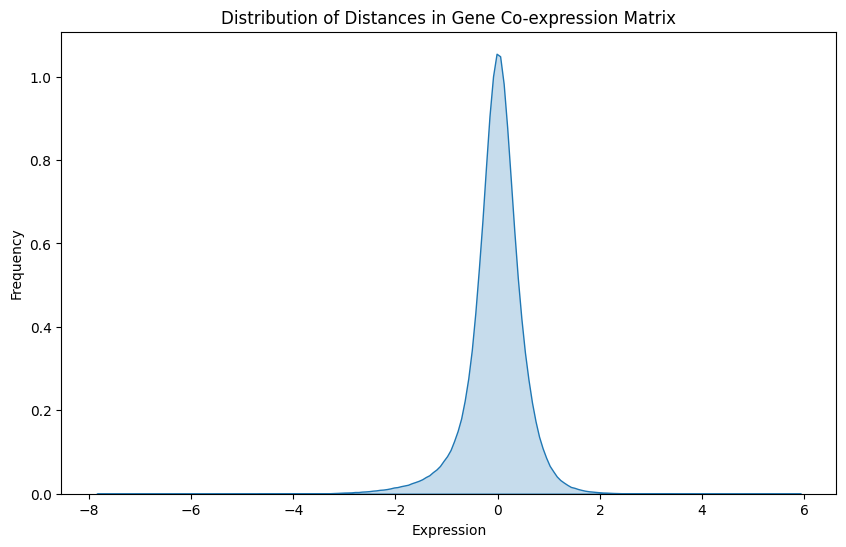

In [16]:
norm_test(df_Gao_Original)

In [18]:
gene_map = pd.read_table('//Backup/home/chenyupeng/DATA/biomart_mart_export.txt', sep='\t')
gene_map.head()

,id,GeneType,gene,GeneSynonym
0,ENSG00000210049,Mt_tRNA,MT-TF,MTTF
1,ENSG00000210049,Mt_tRNA,MT-TF,trnF
2,ENSG00000211459,Mt_rRNA,MT-RNR1,12S
3,ENSG00000211459,Mt_rRNA,MT-RNR1,MOTS-c
4,ENSG00000211459,Mt_rRNA,MT-RNR1,MTRNR1


In [92]:
Label_Gao=pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv',index_col=0).iloc[:,-2:]
Label_Gao

,OS time,death
T112,16.0,0
T113,17.0,0
T123,6.0,1
T125,3.0,1
T127,16.0,0
...,...,...
T1027,7.0,1
T1031,11.0,0
T1041,11.0,0
T1043,11.0,0


In [94]:

# 在gene列之外的gene
gene=df_Gao_Original.index.isin(gene_map['gene'])
fm_gene=df_Gao_Original[gene]
fm_gs=df_Gao_Original.loc[~gene,:]
gene_synonym = df_Gao_Original[(~df_Gao_Original.index.isin(gene_map['gene']))].index.isin(gene_map['GeneSynonym'])
fm_gs=fm_gs[gene_synonym]
# Transfer gene name to ensembl id
ensg_gene = gene_map.set_index('gene')
ensg_gs = gene_map.set_index('GeneSynonym')

ensg_gene = ensg_gene.loc[fm_gene.index,:]['id']
# keep first duplicated gene name
ensg_gene = ensg_gene[(~ensg_gene.index.duplicated(keep='first'))]
fm_gene.index = ensg_gene

ensg_gs = ensg_gs.loc[fm_gs.index,:]['id']
# keep first duplicated genesynonym name
ensg_gs = ensg_gs[(~ensg_gs.index.duplicated(keep='first'))]
fm_gs.index = ensg_gs

fm = pd.concat([fm_gene, fm_gs], axis=0)
# 删除癌旁组织
sam = df_Gao.index
fm_Gao = fm[sam].T
fm_Gao.head()


id,ENSG00000275316,ENSG00000282745,ENSG00000278042,ENSG00000211935,ENSG00000211952,ENSG00000277574,ENSG00000282639,ENSG00000163694,ENSG00000033178,ENSG00000117868,...,ENSG00000130349,ENSG00000186522,ENSG00000134444,ENSG00000133706,ENSG00000282302,ENSG00000163946,ENSG00000186260,ENSG00000166595,ENSG00000142197,ENSG00000113163
T112,0.589275,-0.431827,-0.742205,-0.476795,-1.092085,-0.129644,-0.450593,0.499752,-0.717421,-0.436857,...,0.311610,-0.686862,0.281528,0.054946,0.309717,0.158702,-0.223069,0.813314,-0.395030,-0.056147
T113,-0.042816,-0.614849,-1.096484,-0.691952,-1.251609,-0.101962,-0.989778,0.518507,0.287360,-0.381399,...,0.531864,-0.573388,0.014605,0.036103,-0.005655,0.006923,-0.143576,0.275326,-0.951312,-0.295170
T123,-0.062434,-1.043460,-1.462146,-0.894658,-1.855076,-0.286874,-1.186649,-0.086198,-0.065745,0.243902,...,0.673627,-1.116429,0.890927,0.437384,-0.667756,0.187397,-0.097094,1.156782,0.092956,0.127989
T125,1.232591,0.426004,0.020010,0.244307,0.074542,0.334532,0.128883,0.094101,0.814446,0.291420,...,0.245204,0.074808,0.560880,-0.360693,0.729265,0.480383,-0.290411,0.698838,0.723492,-0.170313
T127,-0.594934,-0.599542,-0.957436,-0.803558,-1.527752,-0.058993,-1.062545,0.112502,-0.848418,-0.264655,...,0.208409,-0.187122,0.159203,-0.030339,-0.605807,0.336559,0.093238,0.719677,-0.399355,-0.010692


In [95]:
from DATA_preprocess import cox_feature_selection
dataset,cox_p_value = cox_feature_selection(time_col="OS time",event_col="death",feature_matrix=fm_Gao,label_matrix= Label_Gao, process_num=90)
gene_list = pd.DataFrame(index=dataset.columns[:-2],columns=["cox_p_value"],data = cox_p_value ).sort_values("cox_p_value")
gene_list.to_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/genes_Cox.csv")
dataset.head()

Cox univariate regression ...


 84%|████████▍ | 5448/6469 [27:42<07:25,  2.29it/s] 

'ENSG00000104835'


 99%|█████████▊| 6376/6469 [33:16<01:05,  1.41it/s]

'ENSG00000136628'


...

'ENSG00000125354'


 99%|█████████▉| 6411/6469 [33:29<00:24,  2.40it/s]

'ENSG00000125354'


100%|██████████| 6469/6469 [33:39<00:00,  3.20it/s]


,ENSG00000275316,ENSG00000282745,ENSG00000278042,ENSG00000211935,ENSG00000211952,ENSG00000277574,ENSG00000282639,ENSG00000163694,ENSG00000033178,ENSG00000117868,...,ENSG00000134444,ENSG00000133706,ENSG00000282302,ENSG00000163946,ENSG00000186260,ENSG00000166595,ENSG00000142197,ENSG00000113163,OS time,death
T112,0.589275,-0.431827,-0.742205,-0.476795,-1.092085,-0.129644,-0.450593,0.499752,-0.717421,-0.436857,...,0.281528,0.054946,0.309717,0.158702,-0.223069,0.813314,-0.395030,-0.056147,16.0,0
T113,-0.042816,-0.614849,-1.096484,-0.691952,-1.251609,-0.101962,-0.989778,0.518507,0.287360,-0.381399,...,0.014605,0.036103,-0.005655,0.006923,-0.143576,0.275326,-0.951312,-0.295170,17.0,0
T123,-0.062434,-1.043460,-1.462146,-0.894658,-1.855076,-0.286874,-1.186649,-0.086198,-0.065745,0.243902,...,0.890927,0.437384,-0.667756,0.187397,-0.097094,1.156782,0.092956,0.127989,6.0,1
T125,1.232591,0.426004,0.020010,0.244307,0.074542,0.334532,0.128883,0.094101,0.814446,0.291420,...,0.560880,-0.360693,0.729265,0.480383,-0.290411,0.698838,0.723492,-0.170313,3.0,1
T127,-0.594934,-0.599542,-0.957436,-0.803558,-1.527752,-0.058993,-1.062545,0.112502,-0.848418,-0.264655,...,0.159203,-0.030339,-0.605807,0.336559,0.093238,0.719677,-0.399355,-0.010692,16.0,0


In [100]:
dataset_sorted = dataset.loc[:,gene_list.index.to_list()+['OS time','death']]
dataset_sorted.to_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv')

In [101]:
dataset_sorted

,ENSG00000160551,ENSG00000121310,ENSG00000134240,ENSG00000161267,ENSG00000166347,ENSG00000100889,ENSG00000187758,ENSG00000122965,ENSG00000274768,ENSG00000136261,...,ENSG00000104835,ENSG00000104835,ENSG00000136628,ENSG00000136628,ENSG00000125354,ENSG00000125354,ENSG00000125354,ENSG00000125354,OS time,death
T112,0.056267,0.449372,0.262272,0.488765,0.597114,0.147268,-1.033410,0.224695,-0.113145,-0.326188,...,1.298764,0.269675,-0.088968,0.003269,-0.298743,-0.477049,-0.298743,-0.477049,16.0,0
T113,0.072541,-0.259499,-1.124935,-0.082551,0.160489,-0.458170,0.023960,0.081203,-0.520136,0.038350,...,0.238344,0.260056,0.132947,0.029526,-0.221878,-0.348669,-0.221878,-0.348669,17.0,0
T123,0.061531,-2.661357,-0.640188,-1.049109,-0.907512,-0.797247,-2.498332,0.683423,-0.806545,0.022778,...,-0.014415,0.579270,0.263218,-0.166178,-0.974570,-1.197173,-0.974570,-1.197173,6.0,1
T125,0.401616,-2.312587,-1.761315,-1.990071,-1.283339,-1.449423,-2.835906,0.007659,-1.286632,1.064229,...,0.025161,-0.013265,-0.476631,-0.093903,-0.327335,0.127020,-0.327335,0.127020,3.0,1
T127,0.383522,-1.062522,0.297422,-0.428575,0.145597,0.276927,-2.745795,0.265698,0.393079,-0.225237,...,0.359582,0.160629,-0.213811,0.052640,-0.807487,-0.611971,-0.807487,-0.611971,16.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,-0.086922,-2.278523,0.545910,0.067783,-0.111242,-0.622956,-0.455524,-0.124028,0.810200,0.126593,...,0.301156,1.484122,0.468611,0.198552,0.695998,-0.319213,0.695998,-0.319213,7.0,1
T1031,-0.780618,-2.308700,0.372938,-1.315420,-0.167305,-1.304941,-1.723870,0.211118,-0.265364,0.434644,...,-0.145059,-0.907771,0.210270,-0.051747,0.874705,-0.014114,0.874705,-0.014114,11.0,0
T1041,-0.647184,0.236735,-1.575152,1.212008,-0.129592,0.437007,-1.878170,0.246144,0.268650,0.609606,...,0.309024,-0.562364,0.166776,0.294285,-0.281094,-0.860142,-0.281094,-0.860142,11.0,0
T1043,-0.192647,-1.012226,1.697420,-0.293384,0.166860,0.008526,-0.763361,-0.400146,0.374723,0.088998,...,-0.541906,-0.725886,0.213465,0.171875,0.341744,0.029237,0.341744,0.029237,11.0,0


In [103]:
genes_STRING=pd.read_csv("/Backup/home/chenyupeng/DATA/Graph/STRING/clusters.protein.ensg.csv")['protein_id'].to_list()
geneSTR = gene_list[gene_list.index.isin(genes_STRING)].index.tolist()
dataset_sorted_STR = dataset.loc[:,geneSTR+['OS time','death']]
dataset_sorted_STR.to_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv')

In [ ]:
df_Gao_ori_proc = pd.concat([dataset, Label_Gao],axis=1)
df_Gao_ori_proc

In [ ]:
# 删失率

In [8]:
import pandas as pd
df_Gao = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv',index_col=0)
df_JX = pd.read_csv('/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/Jiang&Xing/dataset.csv',index_col=0)

In [9]:
df_JX['death'].sum()/df_JX.shape[0]

0.3359683794466403

In [10]:
df_JX

,ENSG00000152620,ENSG00000114054,ENSG00000243989,ENSG00000185813,ENSG00000156110,ENSG00000066583,ENSG00000108439,ENSG00000248098,ENSG00000148218,ENSG00000175198,...,ENSG00000084764,ENSG00000105401,ENSG00000162910,ENSG00000011405,ENSG00000075336,ENSG00000120509,ENSG00000112739,ENSG00000073050,OS time,death
X102T,1.586959,1.033531,2.019756,1.141500,0.893730,1.351021,1.362679,0.905801,1.640677,0.703119,...,-0.055847,0.938186,-7.430450,-1.004980,-0.576213,-7.430450,-1.061885,-0.831592,8.0,0
X12004T,1.749402,1.290763,2.042465,1.189808,1.233152,1.340208,1.512061,1.004823,1.793270,1.094663,...,-0.331962,1.110709,-0.820903,-1.301611,-7.430450,-7.430450,-7.430450,-0.915485,19.0,0
X1210T,1.405871,1.249069,2.120509,1.153055,0.871788,1.349256,1.556462,0.606872,1.434898,0.952738,...,-0.129284,1.126106,-7.430450,-1.119952,-7.430450,-0.478308,-0.840783,-0.983225,19.0,0
X12191T,1.723655,1.115934,1.834155,1.289143,1.313605,1.413843,1.644404,0.771879,1.829449,0.915561,...,-0.393495,1.299982,-0.452970,-7.430450,-7.430450,-0.157550,-0.945638,-1.105709,19.0,0
X1275T,1.822281,1.371543,1.841639,1.223102,1.408110,1.459666,1.719506,0.715761,1.661622,1.080080,...,-0.684121,1.281933,-0.953734,-2.284136,-0.193092,-7.430450,-0.605191,-0.627824,19.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452T,1.362334,1.062769,0.531288,0.088153,0.507765,-0.059365,0.478928,-0.173338,0.650124,0.831405,...,-0.373912,0.107715,-1.484896,0.716454,-0.862912,-7.430450,-1.701885,-0.733641,5.0,0
2453T,1.308782,1.142016,1.491984,0.546400,0.920541,0.318215,1.459738,-0.169726,1.125441,0.587342,...,-0.595917,0.428494,-0.915111,-7.430450,-7.430450,-0.377661,-7.430450,-0.403310,6.0,0
2458T,1.648832,0.860402,0.644151,0.629706,0.542850,0.532607,0.510932,-0.517406,0.548200,0.546143,...,-0.525254,0.469066,-0.531446,0.522258,-1.432740,-0.442777,-0.649157,0.332475,6.0,0
2467T,1.641308,0.481558,0.818013,0.053029,0.688381,0.098794,0.771962,-0.327101,0.341142,0.356857,...,-0.348040,0.627883,-0.524952,-2.179962,-0.634928,-0.686592,-0.882811,-0.524350,6.0,0


In [1]:
import pandas as pd
import numpy as np
import os
from DATA_preprocess import norm_test

# for cohort in ['GSE14520','GSE54236','GSE76427','GSE76427','GSE144269','ICGC_LIRI','TCGA_LIHC']:
#     fm = pd.read_csv(f'/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/12CohortsAgg_0.8nafilter_CoxSort/{cohort}/features.csv',index_col=0)
#     norm_test(fm)

In [3]:
# JGX
import pandas as pd
import numpy as np
import os
# k-NN 缺失值填充
from sklearn.impute import KNNImputer
# zscore
from sklearn.preprocessing import StandardScaler
from DATA_preprocess import norm_test


In [4]:
df_Gao=pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv',index_col=0)
# df_Gao.head()

In [12]:
# df_jx = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/HCC_PRO/0.5nafilter_CoxSort/STRING/Jiang&Xing/dataset.csv', index_col=0)
# df_jx.head()

In [11]:
pro_clinic = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteomicsCohorts_clinic.csv',index_col=0)  
dfs_JX=[pro_clinic.loc[pro_clinic['cohort']=='Jiang',:],pro_clinic.loc[pro_clinic['cohort']=='xing',:]]
Label_J=pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Jiang/dataset.csv',index_col=0).iloc[:,-2:]
Label_X=pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Xing/dataset.csv',index_col=0).iloc[:,-2:]

Labels_JX=pd.concat([Label_J,Label_X],axis=0)
fms_JX=[]
for df in dfs_JX:
    fm = df.iloc[:,8:]
    fm_nafilt = fm.loc[:,(fm.isna().sum(axis=0)/fm.shape[0])<0.5]
    
    # k-nn imputation
    imputer = KNNImputer(n_neighbors=10)
    # impute missing values
    imputed_data = imputer.fit_transform(fm_nafilt)
    # convert to pandas dataframe
    imputed_df = pd.DataFrame(imputed_data, columns=fm_nafilt.columns, index=fm_nafilt.index)
    fms_JX.append(imputed_df)

In [14]:
df_j = pd.read_csv("/Backup/home/chenyupeng/DATA/Proteomic/Jiang-Nature-2019.ensg.intensity.csv",index_col = 0)
df_j.head()

,Protein.names,Symbol,L076P,L057P,L058P,L066P,L063P,L064P,L006P,L008P,...,L083T,L084T,L086T,L089T,L090T,L098T,L102T,L104T,L105T,Ensembl_ID
ID,,,,,,,,,,,,,,,,,,,,,
O43704,Sulfotransferase family cytosolic 1B member 1,SULT1B1,14157414.0,21277931.7,22838451.9,38855559.5,9722121.0,17496082.3,31958577.6,20745117.6,...,184452.8,2031322.9,NaN,2911709.2,NaN,2830471.3,80095.1,65280.6,1157873.8,ENSG00000173597
O15245,Solute carrier family 22 member 1,SLC22A1,9769514.0,22229896.9,11997464.1,8744885.1,8018312.4,17116195.4,18190474.0,17783105.3,...,NaN,5556075.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000175003
O95210,Starch-binding domain-containing protein 1,STBD1,30723619.5,43390655.3,42880823.6,36607620.7,42820895.8,46863375.4,38579219.9,50727168.3,...,5088286.1,17582848.9,5206074.7,403964.3,2667421.4,16768312.5,679104.9,19611380.3,3680836.2,ENSG00000118804
P32754,4-hydroxyphenylpyruvate dioxygenase,HPD,530194465.0,650273325.3,670439522.6,395709006.8,454709408.4,597898006.4,545084722.0,580873608.9,...,134466929.4,171422568.7,164425.8,NaN,11447579.9,23035195.3,8564825.0,273658504.4,28550712.0,ENSG00000158104
O43708,Maleylacetoacetate isomerase,GSTZ1,150879889.9,228241980.5,336132295.2,213918536.9,136540752.2,125047583.4,171831032.7,211877359.9,...,17527118.2,61300298.0,24767924.0,6813777.4,13318296.1,13915447.0,20656734.7,32940596.1,17601303.4,ENSG00000100577


In [45]:
j_fms = df_j.iloc[:,100:-1]
j_fms.shape

(1269, 101)

In [119]:
df_clinic = pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/HCC.ensg .csv",index_col=0)
df_clinic.head()
dfs_jxg=[df_clinic.loc[df_clinic['cohort']=='Jiang',:],df_clinic.loc[df_clinic['cohort']=='xing',:],df_clinic.loc[df_clinic['cohort']=='Gao',:]]
fms_jxg=[]
for df in dfs_jxg:
    fm = df.iloc[:,8:]
    fm_nafilt = fm.loc[:,(fm.isna().sum(axis=0)/fm.shape[0])<0.5]
    
    # k-nn imputation
    imputer = KNNImputer(n_neighbors=10)
    # impute missing values
    imputed_data = imputer.fit_transform(fm_nafilt)
    # convert to pandas dataframe
    imputed_df = pd.DataFrame(imputed_data, columns=fm_nafilt.columns, index=fm_nafilt.index)
    fms_jxg.append(imputed_df)


In [122]:
labels_cohort = []
for i in range(len(fms_jxg)):
    for j in range(fms_jxg[i].shape[0]):
        labels_cohort.append(i)
# labels_cohort

In [120]:
dfjxg = pd.concat(fms_jxg)
dfjxg.dropna(axis=1,inplace=True)
dfjxg

,ENSG00000197756,ENSG00000126777,ENSG00000108187,ENSG00000042493,ENSG00000099250,ENSG00000173692,ENSG00000110245,ENSG00000075420,ENSG00000105640,ENSG00000077549,...,ENSG00000139719,ENSG00000062485,ENSG00000047315,ENSG00000160293,ENSG00000135842,ENSG00000166825,ENSG00000100106,ENSG00000169504,ENSG00000108064,ENSG00000166337
X102T,1.584460e+08,1.547860e+07,2.551298e+08,3.300009e+07,1.758038e+05,1.791395e+07,2.791326e+08,1.599956e+06,1.282689e+08,6.844127e+07,...,6.197096e+06,1.263219e+08,1.526732e+06,4.127805e+06,3.060633e+05,2.275169e+07,307975.823242,7.133381e+07,2.971724e+06,1.262517e+06
X12004T,1.221258e+08,2.060752e+07,3.292895e+08,1.333734e+07,2.678621e+06,2.179791e+07,7.887953e+07,3.410808e+05,9.505495e+07,8.643454e+07,...,6.518647e+05,9.883529e+07,1.622696e+06,2.796272e+06,2.144254e+06,2.466775e+07,428615.675707,5.327517e+07,4.899511e+06,1.138320e+06
X1210T,1.373957e+08,1.839460e+07,5.043836e+06,2.403766e+07,7.336049e+05,2.578054e+07,2.421736e+08,1.626815e+06,1.972563e+08,1.143964e+08,...,1.286186e+06,7.604034e+07,9.607577e+05,6.221542e+06,1.474160e+06,5.387162e+07,476345.509758,6.001628e+07,8.330805e+05,6.314690e+05
X12191T,9.922374e+07,1.386811e+07,2.867093e+08,5.588639e+06,3.982461e+05,1.699005e+07,1.572388e+08,7.734940e+04,5.670410e+07,9.488939e+07,...,2.583339e+05,1.460082e+08,7.520582e+05,2.417327e+06,1.491052e+05,1.632513e+07,234838.005280,5.187688e+07,7.623958e+06,4.397141e+05
X1275T,4.938408e+07,3.583078e+07,1.082945e+08,3.832258e+07,7.184199e+05,2.262798e+07,2.086208e+08,5.149429e+05,1.242314e+08,7.776077e+07,...,1.612079e+06,1.388315e+08,1.121835e+06,2.783229e+06,2.409513e+05,1.835535e+06,202278.993821,1.431229e+07,7.355385e+06,1.076036e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,1.073518e+00,1.564285e+00,5.902113e-01,4.144859e-01,5.952314e-01,1.045553e+00,2.290770e+00,6.118839e-01,1.086546e+00,1.234398e+00,...,1.214437e+00,2.273101e+00,1.000000e+00,8.227553e-01,6.456642e-01,7.873267e-01,0.910849,8.751053e-01,6.315421e-01,1.445281e+00
T1031,9.846953e-01,1.539189e+00,3.981115e-01,2.679103e+00,6.531325e-01,8.181475e-01,3.369051e-01,8.824258e-01,9.053681e-01,1.007967e+00,...,1.211693e+00,1.295729e+00,1.443099e+00,1.107279e+00,1.303854e+00,7.351443e-01,0.959246,6.437380e-01,1.286573e+00,1.006099e+00
T1041,1.080818e+00,1.477562e+00,5.737815e-01,2.757118e+00,6.419469e-01,6.435050e-01,4.157388e-01,6.947838e-01,8.210920e-01,1.062590e+00,...,1.024124e+00,3.046114e+00,1.196971e+00,6.842088e-01,6.272401e-01,5.982217e-01,1.012347,1.288263e+00,1.874262e+00,9.608803e-01
T1043,1.359512e+00,1.276485e+00,1.050290e+00,1.060584e+00,6.071674e-01,1.100356e+00,1.159976e+00,9.212855e-01,1.145768e+00,1.027184e+00,...,1.065939e+00,2.207021e+00,1.008296e+00,1.027574e+00,1.197916e+00,5.961597e-01,1.076031,6.685319e-01,1.602676e+00,1.020713e+00


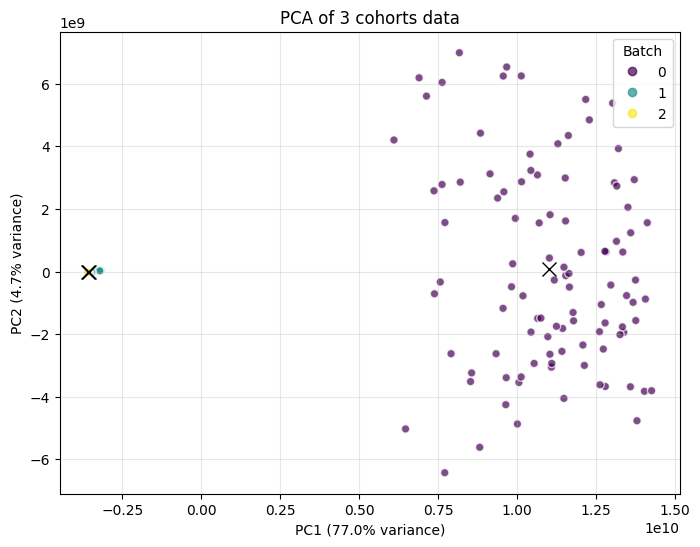

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# pca  = PCA(n_components=2).fit_transform(dfjxg)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(dfjxg)
# plt.scatter(pca[:,0], pca[:,1], c=labels_cohort)
batch_labels = labels_cohort
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_coords[:, 0], 
    pca_coords[:, 1], 
    c=batch_labels, 
    cmap='viridis',
    alpha=0.7,
    edgecolor='w'
)
# 添加解释方差比
var_ratio = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_ratio[0]:.1%} variance)")
plt.ylabel(f"PC2 ({var_ratio[1]:.1%} variance)")

# 添加图例和标题
legend = plt.legend(
    *scatter.legend_elements(),
    title="Batch",
    loc="upper right"
)
plt.title("PCA of 3 cohorts")
plt.grid(alpha=0.3)

# 4. 显示批次中心点（可选）
for batch in np.unique(batch_labels):
    mask = np.array(batch_labels) == batch
    center = pca_coords[mask].mean(axis=0)
    plt.plot(center[0], center[1], 'kx', markersize=10)

plt.show()

In [ ]:
from combat.pycombat import pycombat
dfjxg_cor = pycombat(data = dfjxg.T,batch = labels_cohort,par_prior=True)
dfjxg_cor

Found 3 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


,X102T,X12004T,X1210T,X12191T,X1275T,X1294T,X269T,X277T,X279T,X283T,...,T983,T1013,T1015,T1021,T1025,T1027,T1031,T1041,T1043,T1045
ENSG00000197756,3.154501e+07,1.346462e+07,2.106602e+07,2.063853e+06,-2.274658e+07,4.148634e+07,4.948631e+07,3.961820e+07,-2.795933e+07,1.215483e+07,...,4.580852e+07,4.535468e+07,5.162670e+07,5.138918e+07,4.514698e+07,4.602782e+07,4.423122e+07,4.617547e+07,5.181260e+07,3.439035e+07
ENSG00000126777,-1.860050e+05,2.286207e+06,1.219551e+06,-9.622821e+05,9.624036e+06,-8.339110e+05,1.409587e+07,2.924550e+06,6.783029e+05,5.556337e+06,...,8.146601e+06,8.146601e+06,8.146602e+06,8.146603e+06,8.146607e+06,8.146604e+06,8.146604e+06,8.146604e+06,8.146603e+06,8.146602e+06
ENSG00000108187,9.447004e+07,1.303687e+08,-2.658983e+07,1.097568e+08,2.339102e+07,2.430014e+06,2.718190e+07,4.772360e+05,1.900717e+08,8.557213e+07,...,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07,2.947318e+07
ENSG00000042493,-1.100976e+07,-2.002386e+07,-1.511846e+07,-2.357614e+07,-8.569740e+06,-2.048957e+07,-1.209971e+07,-2.342802e+07,-2.264344e+07,-2.556419e+07,...,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07,2.866874e+07
ENSG00000099250,-5.901265e+05,6.124551e+05,-3.221080e+05,-4.832449e+05,-3.294043e+05,-3.229931e+05,1.655486e+06,6.322213e+05,1.026074e+06,-1.225695e+05,...,6.993660e+05,6.993647e+05,6.993672e+05,6.993656e+05,6.993651e+05,6.993645e+05,6.993646e+05,6.993646e+05,6.993645e+05,6.993653e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000166825,-5.976517e+06,-5.064576e+06,8.834847e+06,-9.035200e+06,-1.593145e+07,-1.167336e+07,9.195641e+05,2.318660e+07,2.635011e+06,3.007628e+06,...,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07,1.768733e+07
ENSG00000100106,3.935954e+04,9.488479e+04,1.168527e+05,5.697402e+03,-9.288088e+03,-5.920310e+04,1.145926e+05,1.448214e+05,9.386254e+04,4.418387e+03,...,2.362598e+05,2.362590e+05,2.362601e+05,2.362600e+05,2.362599e+05,2.362598e+05,2.362599e+05,2.362601e+05,2.362603e+05,2.362618e+05
ENSG00000169504,2.238961e+07,1.340441e+07,1.675849e+07,1.270868e+07,-5.981849e+06,6.209283e+06,2.759285e+07,3.732885e+07,2.125654e+07,9.671163e+06,...,1.295898e+07,1.295901e+07,1.295899e+07,1.295898e+07,1.295898e+07,1.295899e+07,1.295898e+07,1.295900e+07,1.295898e+07,1.295900e+07
ENSG00000108064,-1.527314e+05,7.925898e+05,-1.201450e+06,2.128566e+06,1.996867e+06,1.178251e+07,3.475796e+05,4.347997e+05,-1.240048e+06,1.695172e+06,...,1.755473e+06,1.755469e+06,1.755469e+06,1.755472e+06,1.755475e+06,1.755470e+06,1.755473e+06,1.755477e+06,1.755475e+06,1.755471e+06


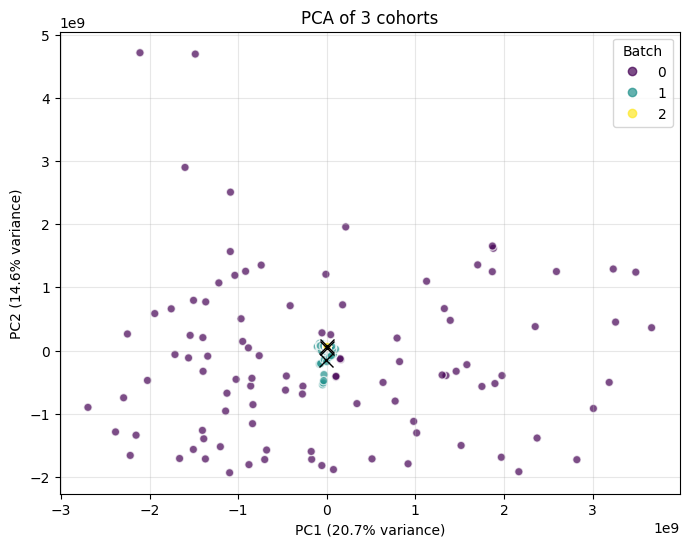

In [135]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(dfjxg_cor.T)
# plt.scatter(pca[:,0], pca[:,1], c=labels_cohort)
batch_labels = labels_cohort
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_coords[:, 0], 
    pca_coords[:, 1], 
    c=batch_labels, 
    cmap='viridis',
    alpha=0.7,
    edgecolor='w'
)
# 添加解释方差比
var_ratio = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_ratio[0]:.1%} variance)")
plt.ylabel(f"PC2 ({var_ratio[1]:.1%} variance)")

# 添加图例和标题
legend = plt.legend(
    *scatter.legend_elements(),
    title="Batch",
    loc="upper right"
)
plt.title("PCA of 3 cohorts")
plt.grid(alpha=0.3)

# 4. 显示批次中心点（可选）
for batch in np.unique(batch_labels):
    mask = np.array(batch_labels) == batch
    center = pca_coords[mask].mean(axis=0)
    plt.plot(center[0], center[1], 'kx', markersize=10)

plt.show()

In [104]:
for i in range(3):  
    # norm_test(fms_jxg[i])
    print(f"fms_jxg{i} shape:", fms_jxg[i].shape)


fms_jxg0 shape: (101, 3219)
fms_jxg1 shape: (152, 2916)
fms_jxg2 shape: (159, 3351)


data standard deviation: 0.945187978521758


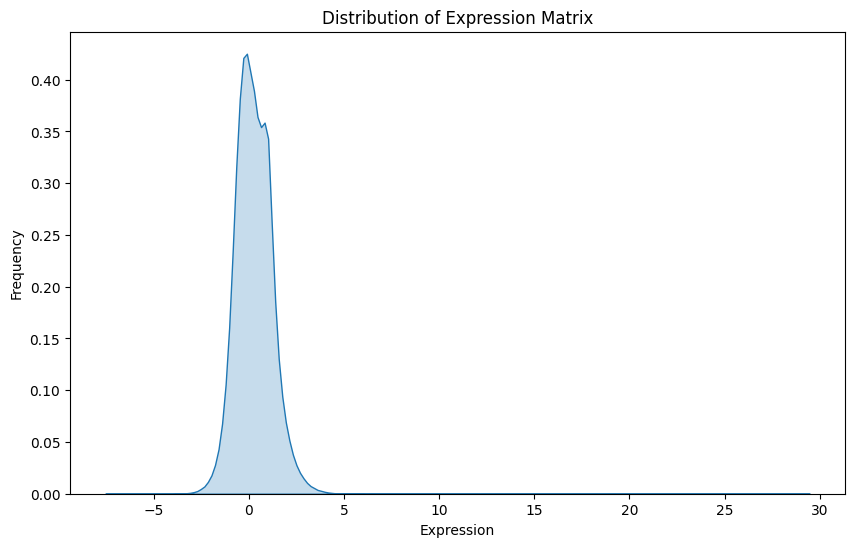

In [59]:
norm_test(pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteomicsCohorts_clinic.csv",index_col=0).iloc[:,8:])

data standard deviation: 0.6466147809131972


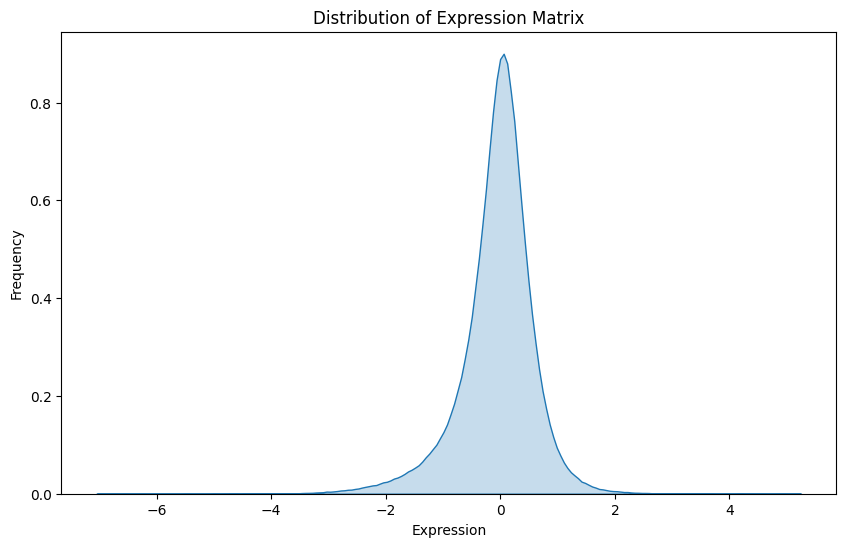

In [54]:
norm_test(pd.read_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/ProteinCohorts_0.5nafilter_CoxSort/STRING/Gao/dataset.csv",index_col=0).iloc[:,:-2])

data standard deviation: 221697370.25014144


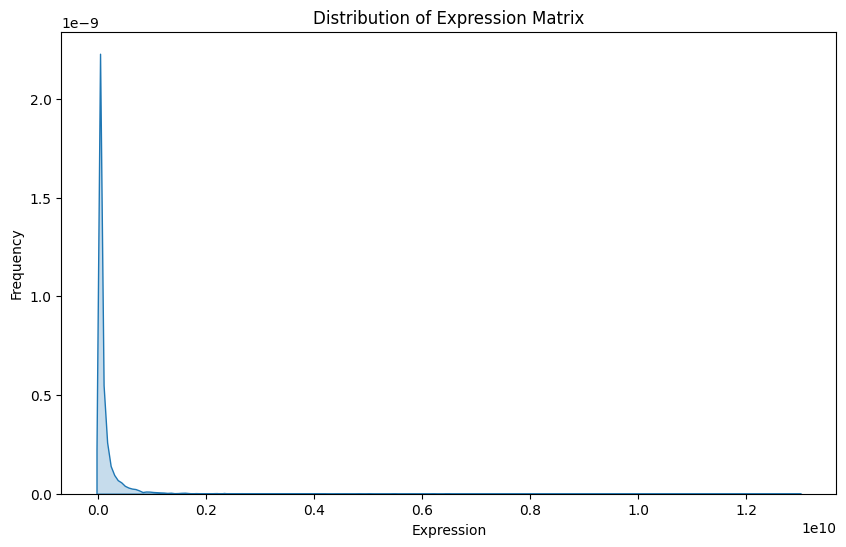

In [31]:
norm_test(df_j.iloc[:,100:-1].values)

In [20]:
fms_JX[0].index

Index(['X102T', 'X12004T', 'X1210T', 'X12191T', 'X1275T', 'X1294T', 'X269T',
       'X277T', 'X279T', 'X283T',
       ...
       'XH06T', 'XH08T', 'XH10T', 'XH12T', 'XH16T', 'XH17T', 'XL03T', 'XL07T',
       'XL09T', 'XL11T'],
      dtype='object', length=101)

In [16]:
fms_JX[0].shape

(101, 4242)

In [34]:
fms_JX[0]

,ENSG00000130402,ENSG00000185567,ENSG00000099968,ENSG00000072786,ENSG00000142875,ENSG00000166479,ENSG00000132670,ENSG00000186687,ENSG00000141556,ENSG00000125656,...,ENSG00000153071,ENSG00000111716,ENSG00000133103,ENSG00000041802,ENSG00000165283,ENSG00000178741,ENSG00000168653,ENSG00000198771,ENSG00000155849,ENSG00000123472
X102T,1.935233,-0.920895,0.604409,-1.421730,-0.150509,-0.825710,-0.995284,0.092092,-0.713990,0.656972,...,0.152114,1.415966,-1.090221,-0.600973,1.147340,0.826847,0.541268,-1.127654,-0.297029,-0.042605
X12004T,1.968161,-1.067533,0.672476,-0.644646,-0.105505,-0.436243,-0.780847,-0.388429,-0.715469,0.559557,...,-0.269229,1.161713,-1.277900,-2.332331,0.719874,0.861345,0.830534,-0.650482,-0.376746,-0.064771
X1210T,2.065109,-1.309850,0.788334,-0.564842,-0.098499,-1.025837,-1.349109,0.104525,-0.371872,0.529990,...,-0.570490,1.202331,-0.698965,-1.105362,0.883314,0.951998,0.928356,-0.762871,-0.080592,0.046753
X12191T,1.970996,-1.426310,0.717981,-0.485937,-0.372158,-0.939380,-1.266095,0.119346,-0.702430,0.445522,...,-1.272244,1.100445,-0.476704,-0.424695,0.721482,0.806517,0.373509,-0.638847,-0.392894,0.083999
X1275T,1.898631,-1.572643,0.860266,-0.647861,-0.240671,-1.082922,-0.844518,-0.295433,-0.773722,0.748116,...,-1.599542,1.008465,-0.325762,-1.511212,0.959990,0.968437,-0.155463,-1.106350,-0.044705,0.090234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XH17T,2.261514,-0.750618,0.394250,0.065650,0.106924,0.332487,-1.181758,-0.598144,-0.139431,0.592074,...,0.256830,1.813305,-0.192798,-1.126562,0.664529,0.177012,0.482208,0.609529,0.727626,-0.565404
XL03T,2.084390,-1.130355,0.795869,-0.339780,-0.318189,-0.072577,-0.735839,0.165861,-0.292197,0.504436,...,-0.130914,1.532382,-0.665140,-0.948076,0.649522,0.813391,0.823788,-0.491519,-0.490091,-0.414287
XL07T,2.145890,-0.937065,-0.015405,0.137589,0.115645,0.288432,-0.671466,-0.548981,-0.224428,0.654978,...,0.418154,2.062340,-0.381808,-1.784946,0.898691,1.330133,1.099225,0.173301,0.496681,-0.924562
XL09T,2.254899,-0.314182,0.466615,-0.155055,0.179142,-0.356448,-0.736405,-0.143818,0.078865,0.513130,...,-0.000101,1.886468,-0.868655,-1.404123,0.602667,0.946709,0.667123,-0.107620,-0.222467,0.003624


<AxesSubplot: >

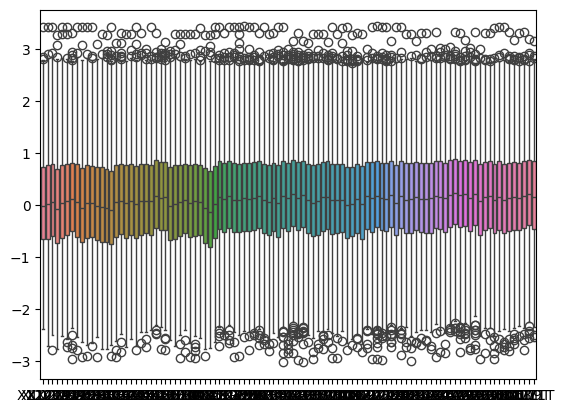

In [38]:
import seaborn as sns
sns.boxplot(data=fms_JX[0].T)  # 查看样本间分布


<AxesSubplot: >

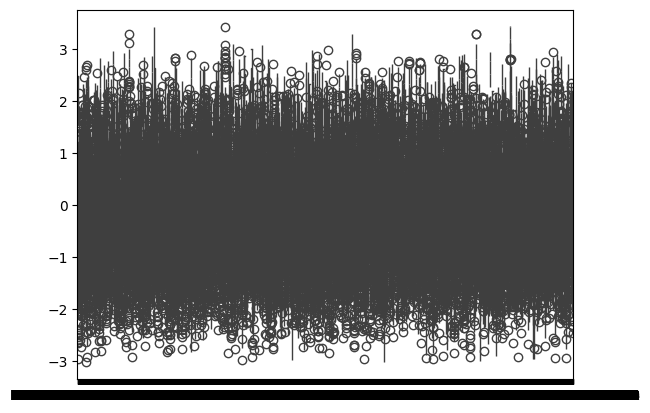

In [39]:
sns.boxplot(data=fms_JX[0])  # 查看蛋白间分布


In [46]:
j_fms.head()

,L076T,L057T,L058T,L066T,L063T,L064T,L006T,L008T,L009T,L012T,...,L082T,L083T,L084T,L086T,L089T,L090T,L098T,L102T,L104T,L105T
ID,,,,,,,,,,,,,,,,,,,,,
O43704,31753364.8,10895396.3,19403501.1,115425246.0,22910271.4,5685619.3,10215045.2,12727588.1,9219187.6,17261955.0,...,2165414.1,184452.8,2031322.9,NaN,2911709.2,NaN,2830471.3,80095.1,65280.6,1157873.8
O15245,4732672.7,14451017.1,20965739.7,5224236.0,3207418.9,NaN,678045.2,17373937.0,5786980.2,8848404.1,...,NaN,NaN,5556075.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O95210,61272998.3,81931005.5,68099447.9,52766528.0,35895680.8,61607009.5,25438890.6,17758846.1,43751234.6,28975792.4,...,16693993.0,5088286.1,17582848.9,5206074.7,403964.3,2667421.4,16768312.5,679104.9,19611380.3,3680836.2
P32754,143283061.9,477135712.5,417164432.1,532962529.9,740857814.9,265833721.4,282039280.4,268729160.0,279243161.5,617857006.7,...,3820075.7,134466929.4,171422568.7,164425.8,NaN,11447579.9,23035195.3,8564825.0,273658504.4,28550712.0
O43708,84597393.7,168238749.9,92278275.8,117741676.6,96001248.8,51341700.3,12778024.9,56786929.1,159917056.7,77148775.6,...,20955949.2,17527118.2,61300298.0,24767924.0,6813777.4,13318296.1,13915447.0,20656734.7,32940596.1,17601303.4


In [50]:
j_fms.mean(axis=1)

ID
O43704    8.934352e+06
O15245    4.629103e+06
O95210    2.664819e+07
P32754    2.161601e+08
O43708    4.452718e+07
              ...     
Q9NZJ6    4.485726e+06
Q00G26    1.077084e+06
Q8WV74    2.699512e+06
Q9H330    2.475793e+06
Q9Y694    1.590488e+06
Length: 1269, dtype: float64

In [47]:
j_fms.std(axis=0)

L076T    2.286749e+08
L057T    2.881674e+08
L058T    2.396709e+08
L066T    2.679693e+08
L063T    4.115881e+08
             ...     
L090T    1.044983e+08
L098T    1.369069e+08
L102T    9.741736e+07
L104T    1.764698e+08
L105T    1.256506e+08
Length: 101, dtype: float64

In [48]:
j_fms.mean(axis=0)

L076T    5.288143e+07
L057T    7.365811e+07
L058T    5.242128e+07
L066T    6.779165e+07
L063T    7.516469e+07
             ...     
L090T    2.635999e+07
L098T    2.997497e+07
L102T    2.557129e+07
L104T    3.778095e+07
L105T    3.263500e+07
Length: 101, dtype: float64

In [42]:
fms_JX[0].std(axis=1)

X102T      0.949056
X12004T    0.962335
X1210T     0.948603
X12191T    0.964320
X1275T     0.954454
             ...   
XH17T      0.928841
XL03T      0.913939
XL07T      0.904817
XL09T      0.889129
XL11T      0.919112
Length: 101, dtype: float64

In [41]:
fms_JX[0].mean(axis=1)

X102T      0.058532
X12004T    0.076631
X1210T     0.111501
X12191T    0.011691
X1275T     0.095396
             ...   
XH17T      0.189358
XL03T      0.182658
XL07T      0.219767
XL09T      0.258191
XL11T      0.201787
Length: 101, dtype: float64

In [40]:
fms_JX[0].mean()

ENSG00000130402    2.052403
ENSG00000185567   -1.312631
ENSG00000099968    0.590163
ENSG00000072786   -0.685283
ENSG00000142875   -0.152902
                     ...   
ENSG00000178741    0.768528
ENSG00000168653    0.494603
ENSG00000198771   -0.661531
ENSG00000155849   -0.112696
ENSG00000123472   -0.095634
Length: 4242, dtype: float64

data standard deviation: 0.9352004656718138


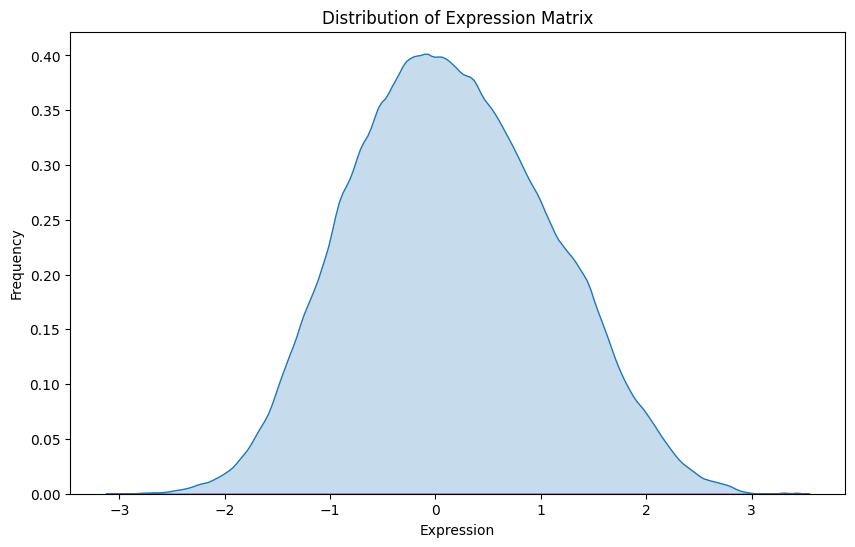

In [13]:
norm_test(fms_JX[0])

0.9351696745872755


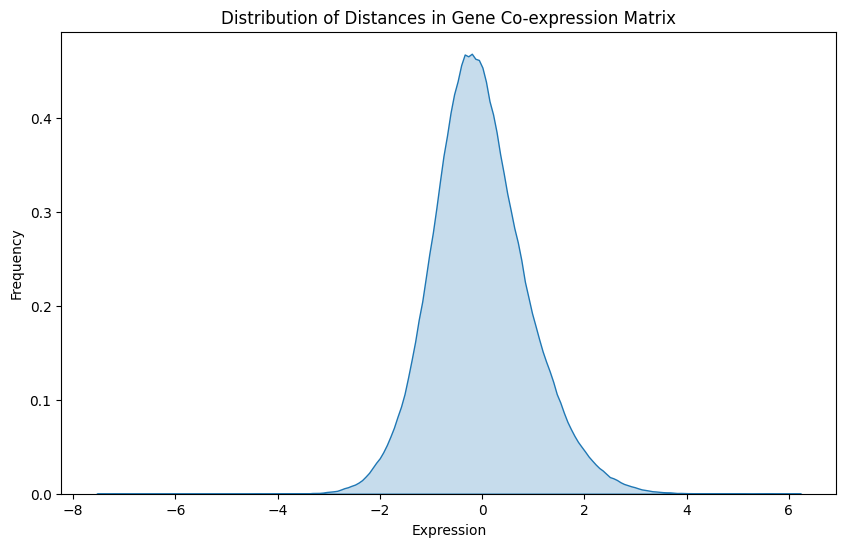

In [27]:
norm_test(fms_JX[1])

In [ ]:
fm_Gao=df_Gao.iloc[:,:-2]
Label_Gao =df_Gao.iloc[:,-2:]
fm_Gao.head()
fms_JX.append(fm_Gao)

In [36]:
fms_JXG = fms_JX

0.999793739759941


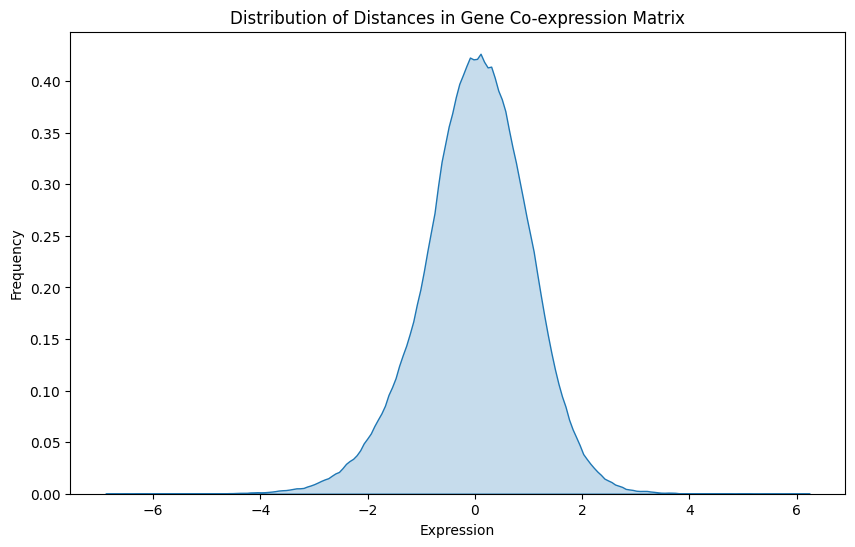

1.0000036699396793


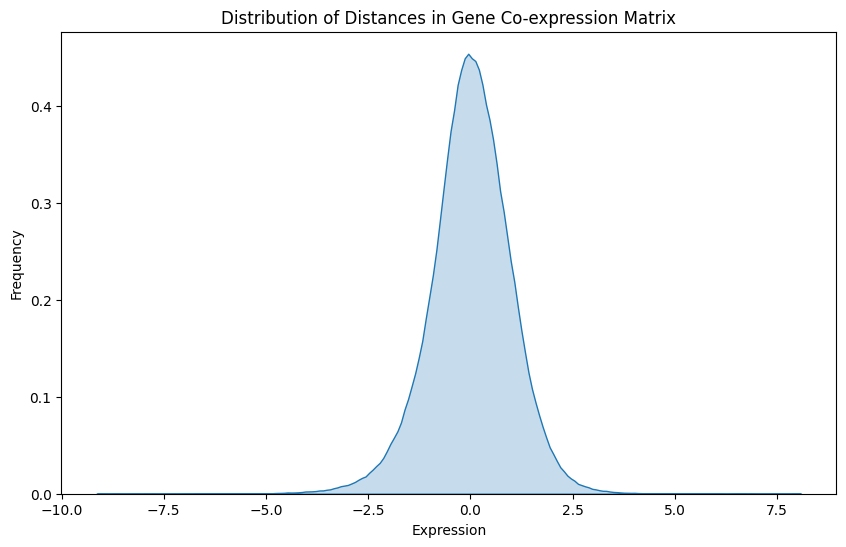

1.0002191366552817


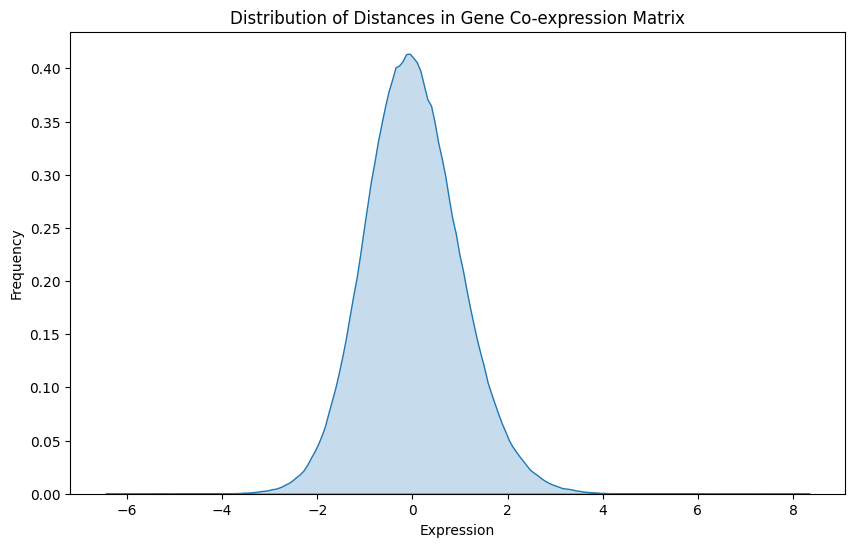

3

In [43]:
from scipy.stats import zscore 
fms_JXG_zscore = []
for fm in fms_JXG:
    # zscore
    feature_matrix = zscore(fm,axis=0)# 每一个基因在所有样本上的均值接近零，方差接近一 
    norm_test(feature_matrix)
    fms_JXG_zscore.append(feature_matrix)
fms_JXG_zscore.__len__()

In [54]:
fms_JXG[2]['ENSG00000130402']

T112     0.742577
T113    -0.457870
T123    -0.417485
T125    -0.329094
T127     0.102441
           ...   
T1027    0.498114
T1031   -0.203810
T1041   -0.266839
T1043   -0.068762
T1045    0.089053
Name: ENSG00000130402, Length: 159, dtype: float64

In [48]:
fm_JXG = pd.concat(fms_JXG, axis=0).dropna(axis=1)
fm_JXG

,ENSG00000130402,ENSG00000185567,ENSG00000166479,ENSG00000141556,ENSG00000168259,ENSG00000005156,ENSG00000157916,ENSG00000189091,ENSG00000087274,ENSG00000064607,...,ENSG00000108091,ENSG00000112531,ENSG00000161016,ENSG00000137161,ENSG00000107937,ENSG00000136842,ENSG00000153071,ENSG00000165283,ENSG00000168653,ENSG00000123472
X102T,1.935233,-0.920895,-0.825710,-0.713990,-0.242914,-1.028056,1.101642,0.413315,-0.181885,-1.310620,...,-0.599231,0.290188,1.838943,0.424033,-0.797537,-0.793124,0.152114,1.147340,0.541268,-0.042605
X12004T,1.968161,-1.067533,-0.436243,-0.715469,-0.285742,-1.291981,1.141576,0.374089,0.380112,-1.786767,...,-0.644114,-0.170249,1.667444,0.675616,-0.871243,-0.150223,-0.269229,0.719874,0.830534,-0.064771
X1210T,2.065109,-1.309850,-1.025837,-0.371872,-0.264099,-1.205381,0.992369,0.360632,0.248207,-1.846722,...,-0.485674,-0.025090,1.847604,0.452868,-0.850062,-0.564293,-0.570490,0.883314,0.928356,0.046753
X12191T,1.970996,-1.426310,-0.939380,-0.702430,-0.112050,-1.350491,1.223614,0.220464,-0.201845,-1.697973,...,-0.610627,-0.765544,1.587618,-0.112587,-0.797435,0.294221,-1.272244,0.721482,0.373509,0.083999
X1275T,1.898631,-1.572643,-1.082922,-0.773722,-0.327761,-0.508336,1.267776,0.534838,-0.791403,-1.441826,...,-0.390495,0.030771,1.881442,0.411269,-0.810396,-0.420049,-1.599542,0.959990,-0.155463,0.090234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,0.498114,0.278292,-0.136732,1.177023,0.494899,0.198930,0.827381,-0.023555,-0.255816,-0.491282,...,0.300397,-0.541589,0.235293,0.706649,0.654970,-0.546572,0.511553,1.073251,-0.770901,1.067211
T1031,-0.203810,-1.005948,0.141528,0.216089,-0.586906,0.756728,-0.286500,0.317938,0.328417,0.433544,...,0.296033,0.477838,0.044361,0.444730,0.344643,-2.220897,-0.458917,-0.006548,0.014200,-0.641518
T1041,-0.266839,0.026394,-0.323115,-0.011752,0.030389,0.176662,0.482758,-0.062282,-0.252913,-0.495741,...,-0.474511,-0.208036,-0.052693,0.173705,0.380377,-0.266607,-0.918970,0.539914,0.878097,0.629778
T1043,-0.068762,-1.288878,-0.149915,1.028112,-0.078248,-0.316320,-0.058987,-0.015897,0.328218,0.341889,...,0.450530,0.179061,0.225171,1.248524,-0.431406,-0.208074,-1.073353,-0.075194,0.791630,0.152948


In [56]:
Labels_JXG=pd.concat([Label_J,Label_X,Label_Gao],axis=0)
Labels_JXG

,OS time,death
X102T,8.0,0
X12004T,19.0,0
X1210T,19.0,0
X12191T,19.0,0
X1275T,19.0,0
...,...,...
T1027,7.0,1
T1031,11.0,0
T1041,11.0,0
T1043,11.0,0


In [ ]:
from DATA_preprocess import cox_feature_selection
os.makedirs("/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/JGX/",exist_ok=True)
dataset,cox_p_value = cox_feature_selection(time_col="OS time",event_col="death",feature_matrix=fm_JXG,label_matrix= Labels_JXG, process_num=90)
gene_list = pd.DataFrame(index=dataset.columns[:-2],columns=["cox_p_value"],data = cox_p_value ).sort_values("cox_p_value")
# os.makedirs("/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/JGX/",exist_ok=True)
gene_list.to_csv("/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/JXG/gene_list.csv")
dataset.head()

Cox univariate regression ...


100%|██████████| 2257/2257 [02:15<00:00, 16.62it/s]


,ENSG00000130402,ENSG00000185567,ENSG00000166479,ENSG00000141556,ENSG00000168259,ENSG00000005156,ENSG00000157916,ENSG00000189091,ENSG00000087274,ENSG00000064607,...,ENSG00000161016,ENSG00000137161,ENSG00000107937,ENSG00000136842,ENSG00000153071,ENSG00000165283,ENSG00000168653,ENSG00000123472,OS time,death
X102T,1.935233,-0.920895,-0.825710,-0.713990,-0.242914,-1.028056,1.101642,0.413315,-0.181885,-1.310620,...,1.838943,0.424033,-0.797537,-0.793124,0.152114,1.147340,0.541268,-0.042605,8.0,0
X12004T,1.968161,-1.067533,-0.436243,-0.715469,-0.285742,-1.291981,1.141576,0.374089,0.380112,-1.786767,...,1.667444,0.675616,-0.871243,-0.150223,-0.269229,0.719874,0.830534,-0.064771,19.0,0
X1210T,2.065109,-1.309850,-1.025837,-0.371872,-0.264099,-1.205381,0.992369,0.360632,0.248207,-1.846722,...,1.847604,0.452868,-0.850062,-0.564293,-0.570490,0.883314,0.928356,0.046753,19.0,0
X12191T,1.970996,-1.426310,-0.939380,-0.702430,-0.112050,-1.350491,1.223614,0.220464,-0.201845,-1.697973,...,1.587618,-0.112587,-0.797435,0.294221,-1.272244,0.721482,0.373509,0.083999,19.0,0
X1275T,1.898631,-1.572643,-1.082922,-0.773722,-0.327761,-0.508336,1.267776,0.534838,-0.791403,-1.441826,...,1.881442,0.411269,-0.810396,-0.420049,-1.599542,0.959990,-0.155463,0.090234,19.0,0


In [65]:
dataset=pd.concat([fm_JXG.loc[:,gene_list.index],Labels_JXG],axis=1)
dataset

,ENSG00000151093,ENSG00000248098,ENSG00000137561,ENSG00000151611,ENSG00000171953,ENSG00000113924,ENSG00000136463,ENSG00000066926,ENSG00000131791,ENSG00000184470,...,ENSG00000197498,ENSG00000239264,ENSG00000137154,ENSG00000082515,ENSG00000162889,ENSG00000011028,ENSG00000082438,ENSG00000125821,OS time,death
X102T,0.189958,0.905801,0.876547,0.532049,-0.586664,1.563077,0.658855,0.313998,0.451195,0.773502,...,-0.733286,1.550156,1.719183,-0.350848,-1.391828,-1.028209,0.082934,-0.673294,8.0,0
X12004T,0.451745,1.004823,0.951723,0.499528,0.316303,1.973822,0.515435,0.820232,0.854156,1.150783,...,-0.800612,1.480613,1.682735,-0.708454,-1.224953,-0.452621,0.563785,-0.259576,19.0,0
X1210T,0.332707,0.606872,0.987859,0.380659,0.250931,1.941035,0.968099,0.749713,0.684021,0.607504,...,-0.754401,1.272194,1.904590,0.027181,-1.122158,-1.474239,-0.106306,0.048251,19.0,0
X12191T,-0.018330,0.771879,0.742059,0.102639,-0.233497,2.126072,0.913993,0.751480,0.823411,1.062819,...,-1.054122,1.430733,1.710713,-0.035993,-0.706571,-1.071381,0.537311,0.076715,19.0,0
X1275T,0.073195,0.715761,0.778763,-0.079729,0.578678,2.127222,1.305388,0.700028,0.430889,0.381720,...,-0.625617,1.567088,1.764199,-0.520701,-0.636753,-1.627515,0.219926,0.091829,19.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T1027,-0.829653,-0.809695,-0.186311,-1.865722,0.410530,0.269273,1.518971,-1.118830,0.971126,-0.307772,...,0.137768,-0.215600,0.235474,0.071946,0.746456,-2.027142,0.311378,0.775760,7.0,1
T1031,-0.301551,-0.530850,-0.602160,-0.159116,-0.526154,-1.331939,0.367840,-0.645106,-0.126420,0.212901,...,-0.107601,-0.174790,0.028922,0.200085,0.155301,-1.177994,0.756984,-0.396978,11.0,0
T1041,1.053290,1.035905,1.558038,1.172784,0.400072,0.503167,1.325448,0.694534,0.243897,1.479670,...,0.626302,-0.437904,-0.178611,1.100595,0.463712,-2.119353,1.219419,1.093700,11.0,0
T1043,0.588617,-0.155626,-0.554378,0.329809,-0.261357,0.219503,0.476604,0.808058,0.513675,0.702473,...,-1.272956,0.726720,0.070504,0.262372,0.255442,-0.893025,0.022636,0.383889,11.0,0


In [ ]:
dataset.to_csv('/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/JXG/dataset.csv')

0.8980405527492155


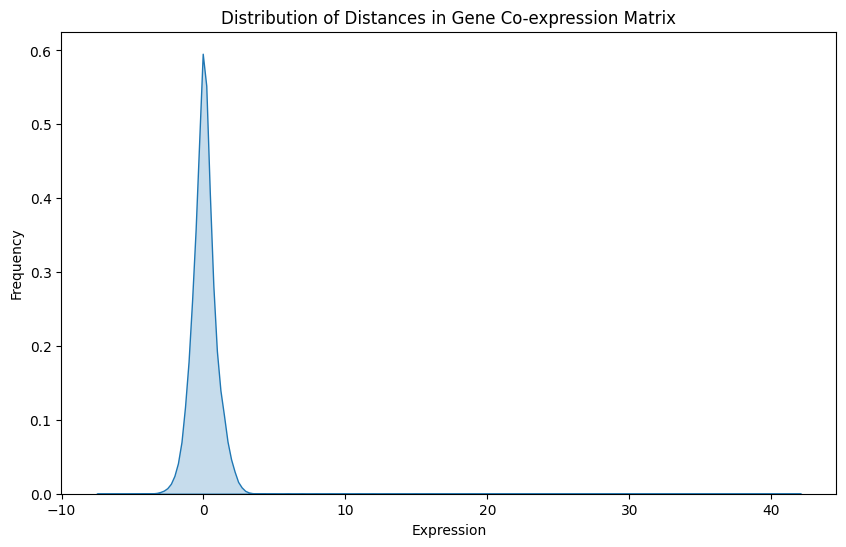

In [67]:
norm_test(dataset)

In [2]:
import pandas as pd
from DATA_preprocess import norm_test

In [4]:
df_JXG = pd.read_csv('/Backup/home/chenyupeng/DATA/PRO/HCC/0.5nafilter_CoxSort/STRING/JXG/dataset.csv', index_col=0)
fm_JXG = df_JXG.iloc[:, :-2]
fm_JXG.head()


,ENSG00000151093,ENSG00000248098,ENSG00000137561,ENSG00000151611,ENSG00000171953,ENSG00000113924,ENSG00000136463,ENSG00000066926,ENSG00000131791,ENSG00000184470,...,ENSG00000197930,ENSG00000008988,ENSG00000197498,ENSG00000239264,ENSG00000137154,ENSG00000082515,ENSG00000162889,ENSG00000011028,ENSG00000082438,ENSG00000125821
X102T,0.189958,0.905801,0.876547,0.532049,-0.586664,1.563077,0.658855,0.313998,0.451195,0.773502,...,0.813968,1.771961,-0.733286,1.550156,1.719183,-0.350848,-1.391828,-1.028209,0.082934,-0.673294
X12004T,0.451745,1.004823,0.951723,0.499528,0.316303,1.973822,0.515435,0.820232,0.854156,1.150783,...,0.894496,0.960286,-0.800612,1.480613,1.682735,-0.708454,-1.224953,-0.452621,0.563785,-0.259576
X1210T,0.332707,0.606872,0.987859,0.380659,0.250931,1.941035,0.968099,0.749713,0.684021,0.607504,...,0.870461,1.756212,-0.754401,1.272194,1.904590,0.027181,-1.122158,-1.474239,-0.106306,0.048251
X12191T,-0.018330,0.771879,0.742059,0.102639,-0.233497,2.126072,0.913993,0.751480,0.823411,1.062819,...,0.847444,1.520661,-1.054122,1.430733,1.710713,-0.035993,-0.706571,-1.071381,0.537311,0.076715
X1275T,0.073195,0.715761,0.778763,-0.079729,0.578678,2.127222,1.305388,0.700028,0.430889,0.381720,...,1.062385,1.291949,-0.625617,1.567088,1.764199,-0.520701,-0.636753,-1.627515,0.219926,0.091829


0.8504302643845584


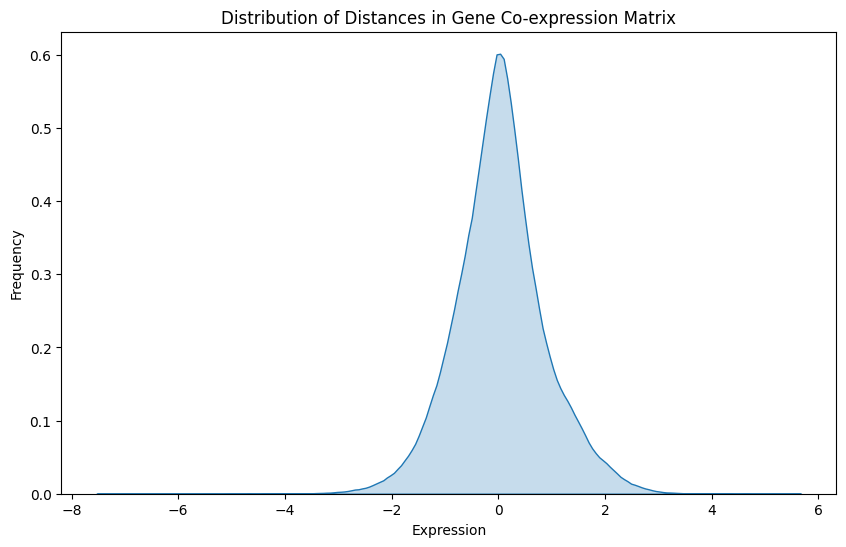

In [5]:
norm_test(fm_JXG)

In [6]:
df_RNA = pd.read_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/HCC_transcript.ensg.csv',index_col=0)
df_RNA.head()

,OS time,death,RFS time,recurrence,BCLC stage,TNM stage,omics,cohort,ENSG00000174306,ENSG00000171806,...,ENSG00000010626,ENSG00000044524,ENSG00000105397,ENSG00000080293,ENSG00000162419,ENSG00000043462,ENSG00000163257,ENSG00000167601,ENSG00000135297,ENSG00000104980
GSM4284625,3.213699,1.0,NaN,NaN,NaN,III,Transcript,GSE144269,0.271142,-0.506879,...,-1.454114,-0.757976,-1.141458,0.388599,-0.633037,-1.284249,0.469650,-1.216742,-0.055331,0.427516
GSM4284647,4.106849,0.0,NaN,NaN,NaN,III,Transcript,GSE144269,0.279187,-0.257501,...,0.771392,0.713571,0.263175,-1.648057,1.562778,0.606729,1.593407,1.674577,-1.057422,-0.898294
GSM4284669,1.183562,1.0,NaN,NaN,NaN,III,Transcript,GSE144269,-1.102177,1.960920,...,-2.080953,-1.750783,-1.403854,-2.103513,-0.287589,-2.700545,1.499571,-2.698035,-0.535582,-0.233308
GSM4284691,3.410959,0.0,NaN,NaN,NaN,NaN,Transcript,GSE144269,0.383975,1.535142,...,-0.150726,-1.996561,0.020101,0.013028,1.837534,0.097431,0.371156,-0.904345,-0.226021,0.719669
GSM4284713,2.879452,1.0,NaN,NaN,NaN,NaN,Transcript,GSE144269,1.098066,0.998771,...,0.235010,-0.778973,0.190000,0.446565,0.217072,-1.514710,-1.304057,-1.381193,-0.038417,-0.194668


In [1]:
# for cohort in ['GSE14520','GSE54236','GSE76427','GSE76427','GSE144269','ICGC_LIRI','TCGA_LIHC']:
#     fm=df_RNA.loc[df_RNA['cohort']==cohort,:]
#     fm = fm.iloc[:,8:]
#     norm_test(fm)

In [8]:
fm_RNA = df_RNA.iloc[:,8:]
fm_RNA

,ENSG00000174306,ENSG00000171806,ENSG00000106397,ENSG00000140320,ENSG00000141179,ENSG00000105607,ENSG00000167468,ENSG00000166801,ENSG00000172262,ENSG00000134256,...,ENSG00000010626,ENSG00000044524,ENSG00000105397,ENSG00000080293,ENSG00000162419,ENSG00000043462,ENSG00000163257,ENSG00000167601,ENSG00000135297,ENSG00000104980
GSM4284625,0.271142,-0.506879,3.082766,1.446516,-0.696056,-0.291080,0.636210,-0.140864,-0.874130,-1.031803,...,-1.454114,-0.757976,-1.141458,0.388599,-0.633037,-1.284249,0.469650,-1.216742,-0.055331,0.427516
GSM4284647,0.279187,-0.257501,-0.351254,-0.268267,-3.089694,-1.871409,-1.508133,0.123236,0.301173,0.234806,...,0.771392,0.713571,0.263175,-1.648057,1.562778,0.606729,1.593407,1.674577,-1.057422,-0.898294
GSM4284669,-1.102177,1.960920,-2.470874,-1.766953,0.988213,-0.904360,-0.581690,0.381209,2.211717,-2.130816,...,-2.080953,-1.750783,-1.403854,-2.103513,-0.287589,-2.700545,1.499571,-2.698035,-0.535582,-0.233308
GSM4284691,0.383975,1.535142,0.823178,-1.565197,-0.183247,-0.983283,0.652686,-0.483933,0.226269,0.717284,...,-0.150726,-1.996561,0.020101,0.013028,1.837534,0.097431,0.371156,-0.904345,-0.226021,0.719669
GSM4284713,1.098066,0.998771,0.796432,-0.571622,0.474255,-0.360814,0.418741,-1.039698,0.963621,-0.524854,...,0.235010,-0.778973,0.190000,0.446565,0.217072,-1.514710,-1.304057,-1.381193,-0.038417,-0.194668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-ZP-A9D4-01A,-0.447288,0.615754,-0.822171,0.621580,1.482488,1.044171,-0.972907,1.168031,-0.127515,-0.427596,...,-0.617712,-0.682167,0.858997,-0.154935,0.072763,-0.796170,0.142839,-0.997954,0.587863,-0.173519
TCGA-ZS-A9CD-01A,0.779335,-0.685665,0.559129,-0.080226,0.525673,-0.305372,0.616218,-1.126435,-0.715122,-0.735531,...,-0.288559,0.730962,-0.083623,-0.417325,0.448268,-0.196358,-0.715394,0.009642,-0.087433,0.374355
TCGA-ZS-A9CE-01A,0.007331,1.042900,0.872862,-1.157059,0.592115,0.186155,0.345608,0.357673,-0.611420,-0.655239,...,0.739175,-0.939622,-0.431887,0.596745,-0.270258,-1.740254,-0.558503,-1.658568,-0.427053,-0.410832
TCGA-ZS-A9CF-01A,1.789317,0.302861,-0.987023,-1.401022,-0.264293,2.292027,-0.412358,1.890083,0.316106,-0.099658,...,0.489989,-0.389010,1.907120,0.027059,0.690743,0.154659,0.401122,-0.214198,-1.372685,-0.578608


In [21]:
ensg2hsa = pd.read_csv('/Backup/home/chenyupeng/DATA/Graph/Reactome/ENSG2HSA.csv',index_col=0)
ensg2hsa.head()

,Gene,Identifier,URL,Orthologous Events,Evidence,Species
0,ENSG00000000419,R-HSA-162699,https://reactome.org/PathwayBrowser/#/R-HSA-16...,Synthesis of dolichyl-phosphate mannose,TAS,Homo sapiens
1,ENSG00000000419,R-HSA-4717374,https://reactome.org/PathwayBrowser/#/R-HSA-47...,Defective DPM1 causes DPM1-CDG,TAS,Homo sapiens
2,ENSG00000000419,R-HSA-4719360,https://reactome.org/PathwayBrowser/#/R-HSA-47...,Defective DPM3 causes DPM3-CDG,TAS,Homo sapiens
3,ENSG00000000419,R-HSA-4719377,https://reactome.org/PathwayBrowser/#/R-HSA-47...,Defective DPM2 causes DPM2-CDG,TAS,Homo sapiens
8,ENSG00000000938,R-HSA-2029481,https://reactome.org/PathwayBrowser/#/R-HSA-20...,FCGR activation,TAS,Homo sapiens


In [22]:
gene_Reac = ensg2hsa['Gene'].unique()
gene_Reac

array(['ENSG00000000419', 'ENSG00000000938', 'ENSG00000000971', ...,
       'ENSG00000292247', 'ENSG00000292249', 'ENSG00000292252'],
      dtype=object)

In [23]:
gene_Reac.__len__()

12528

In [25]:
(fm_RNA.columns.isin(gene_Reac)).sum()

7123

In [28]:
fm_HCCtr_Reac = fm_RNA.loc[:,fm_RNA.columns.isin(gene_Reac)]
Label_HCC = df_RNA.iloc[:,:2]
Label_HCC

,OS time,death
GSM4284625,3.213699,1.0
GSM4284647,4.106849,0.0
GSM4284669,1.183562,1.0
GSM4284691,3.410959,0.0
GSM4284713,2.879452,1.0
...,...,...
TCGA-ZP-A9D4-01A,1.082192,0.0
TCGA-ZS-A9CD-01A,3.797260,1.0
TCGA-ZS-A9CE-01A,3.400000,0.0
TCGA-ZS-A9CF-01A,6.608219,0.0


In [30]:
from DATA_preprocess import cox_feature_selection
import os 
os.makedirs("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/Reactome/",exist_ok=True)
dataset,cox_p_value = cox_feature_selection(time_col="OS time",event_col="death",feature_matrix=fm_HCCtr_Reac,label_matrix= Label_HCC, process_num=90)
gene_list = pd.DataFrame(index=dataset.columns[:-2],columns=["cox_p_value"],data = cox_p_value ).sort_values("cox_p_value")
gene_list.to_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/Reactome/gene_list.csv")
dataset.head()

Cox univariate regression ...


100%|██████████| 7123/7123 [27:49<00:00,  4.27it/s]  


,ENSG00000106397,ENSG00000141179,ENSG00000105607,ENSG00000167468,ENSG00000172262,ENSG00000134256,ENSG00000267796,ENSG00000078699,ENSG00000197562,ENSG00000136854,...,ENSG00000044524,ENSG00000105397,ENSG00000080293,ENSG00000043462,ENSG00000163257,ENSG00000167601,ENSG00000135297,ENSG00000104980,OS time,death
GSM4284625,3.082766,-0.696056,-0.291080,0.636210,-0.874130,-1.031803,1.611082,1.113467,-0.455688,1.795840,...,-0.757976,-1.141458,0.388599,-1.284249,0.469650,-1.216742,-0.055331,0.427516,3.213699,1.0
GSM4284647,-0.351254,-3.089694,-1.871409,-1.508133,0.301173,0.234806,-0.145501,-0.149935,-1.099611,2.514053,...,0.713571,0.263175,-1.648057,0.606729,1.593407,1.674577,-1.057422,-0.898294,4.106849,0.0
GSM4284669,-2.470874,0.988213,-0.904360,-0.581690,2.211717,-2.130816,0.289945,2.159258,0.269960,1.360250,...,-1.750783,-1.403854,-2.103513,-2.700545,1.499571,-2.698035,-0.535582,-0.233308,1.183562,1.0
GSM4284691,0.823178,-0.183247,-0.983283,0.652686,0.226269,0.717284,-0.239026,-0.209343,-0.735819,-0.226672,...,-1.996561,0.020101,0.013028,0.097431,0.371156,-0.904345,-0.226021,0.719669,3.410959,0.0
GSM4284713,0.796432,0.474255,-0.360814,0.418741,0.963621,-0.524854,1.608574,-0.632436,0.255653,0.941804,...,-0.778973,0.190000,0.446565,-1.514710,-1.304057,-1.381193,-0.038417,-0.194668,2.879452,1.0


1.026114700851795


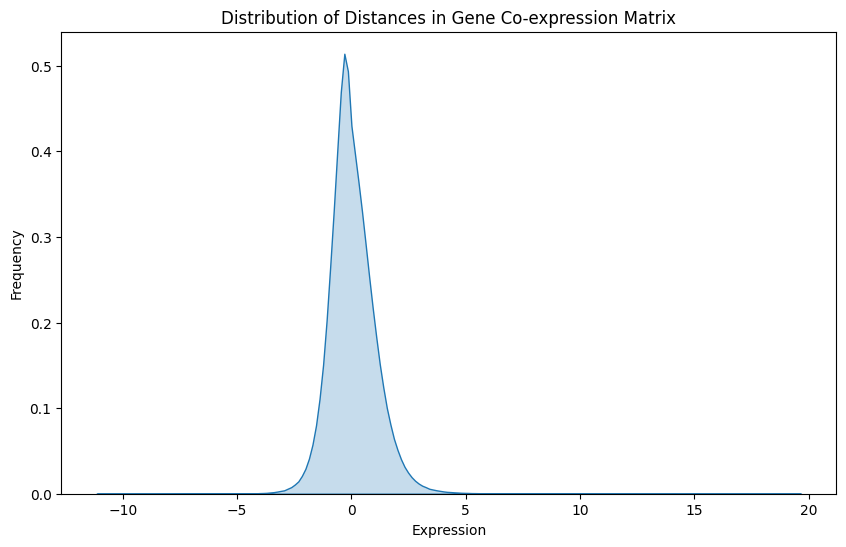

In [48]:
fm_cox = dataset.loc[:,gene_list.index]
norm_test(fm_cox)

In [43]:
from DATA_preprocess import discrete_time_bin
# 转换年为月
Label_HCC['OS month']=Label_HCC['OS time']*12
print(Label_HCC.head(),'\n',Label_HCC['OS month'].max())


             OS time  death   OS month
GSM4284625  3.213699    1.0  38.564384
GSM4284647  4.106849    0.0  49.282192
GSM4284669  1.183562    1.0  14.202740
GSM4284691  3.410959    0.0  40.931507
GSM4284713  2.879452    1.0  34.553425 
 120.82191780821879


In [44]:
time_event_bin = discrete_time_bin(Label_HCC,"OS month",3)
time_event_bin

,OS time,death,OS month
GSM4284625,3.213699,1.0,13.0
GSM4284647,4.106849,0.0,17.0
GSM4284669,1.183562,1.0,5.0
GSM4284691,3.410959,0.0,14.0
GSM4284713,2.879452,1.0,12.0
...,...,...,...
TCGA-ZP-A9D4-01A,1.082192,0.0,5.0
TCGA-ZS-A9CD-01A,3.797260,1.0,16.0
TCGA-ZS-A9CE-01A,3.400000,0.0,14.0
TCGA-ZS-A9CF-01A,6.608219,0.0,27.0


In [46]:
fm_cox['OS time']=time_event_bin['OS month']
fm_cox['death'] = time_event_bin['death']
fm_cox

,ENSG00000142945,ENSG00000134690,ENSG00000117399,ENSG00000108106,ENSG00000182481,ENSG00000100162,ENSG00000152253,ENSG00000137807,ENSG00000167513,ENSG00000136231,...,ENSG00000244122,ENSG00000125968,ENSG00000073670,ENSG00000086159,ENSG00000057468,ENSG00000162433,ENSG00000089818,ENSG00000083720,OS time,death
GSM4284625,1.343766,1.630268,1.311877,1.762040,1.429005,1.991544,1.491910,1.291359,0.589256,-0.374121,...,0.578733,-0.729901,-2.404949,-1.298708,0.297079,0.228159,-2.143522,-0.727707,13.0,1.0
GSM4284647,-0.183750,-0.546680,-0.214475,0.093744,0.224195,-0.210672,-0.409028,0.477417,-1.043386,0.134897,...,-1.577854,0.497398,1.110158,-0.402236,0.009141,-1.610659,0.449107,1.698666,17.0,0.0
GSM4284669,1.361842,1.283557,1.337892,0.883838,1.319570,1.225159,1.689163,1.336118,1.252227,1.611599,...,1.038290,-1.991497,-0.856956,1.366475,0.172352,0.801285,0.705414,1.568410,5.0,1.0
GSM4284691,0.726282,0.583727,0.846902,0.347085,0.547937,0.635983,0.406394,0.485132,0.149370,1.398161,...,-2.683210,-0.499694,-0.905019,-0.732595,0.071985,-0.104937,-0.047676,-0.000917,14.0,0.0
GSM4284713,0.185291,0.143518,0.198219,0.016769,0.335107,-0.432833,-0.060402,-0.010319,0.711773,-0.768498,...,0.679683,-0.970041,1.044246,1.158193,-1.756825,0.477068,1.428332,-0.635199,12.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-ZP-A9D4-01A,-0.504604,-0.053696,-0.406015,-1.122785,-0.650350,-0.573143,-0.313258,-0.440718,-0.221597,-0.577998,...,-0.151958,-0.995977,0.029378,0.528456,-0.343925,0.598399,-0.001599,-0.842200,5.0,0.0
TCGA-ZS-A9CD-01A,-0.793517,-0.651076,-0.686252,-0.257338,-0.286899,-0.517051,-0.991365,-0.896016,-0.666774,-0.655485,...,-0.268950,0.372067,-0.438798,-0.425028,1.734227,0.854806,-0.308674,-0.327084,16.0,1.0
TCGA-ZS-A9CE-01A,-0.713561,-0.126741,-0.255054,-0.466894,-0.591792,-0.609247,-0.757756,-0.458272,-0.182193,-0.388586,...,-0.403816,-0.104128,-0.289079,1.324874,1.363117,0.578470,-0.638944,-0.992916,14.0,0.0
TCGA-ZS-A9CF-01A,1.023830,1.324003,1.145113,-0.158388,-0.605457,0.804855,0.841860,1.143584,0.719523,-0.443622,...,-0.403816,-1.608879,0.058470,-0.422918,0.085542,-0.150547,1.190379,-0.204910,27.0,0.0


In [47]:
fm_cox.to_csv('/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/Reactome/dataset.csv')

In [ ]:
# also sort all genes
os.makedirs("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/All/",exist_ok=True)
dataset_all,cox_p_value_all = cox_feature_selection(time_col="OS time",event_col="death",feature_matrix=fm_RNA,label_matrix= Label_HCC, process_num=90)

Cox univariate regression ...


100%|██████████| 10630/10630 [58:31<00:00,  3.03it/s] 


ValueError: Shape of passed values is (10630, 1), indices imply (10631, 1)

In [ ]:

len(cox_p_value_all)

10630

In [ ]:
gene_list_all = pd.DataFrame(index=dataset_all.columns[:-3],columns=["cox_p_value"],data = cox_p_value_all ).sort_values("cox_p_value")
gene_list_all.to_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/All/gene_list.csv")
fm_all_cox = dataset_all.loc[:,gene_list_all.index]
fm_all_cox['OS time']=time_event_bin['OS month']
fm_all_cox['death'] = time_event_bin['death']

In [ ]:
# filt patients with OS time < 2
fm_all_cox.min()
df1 = fm_all_cox.loc[fm_all_cox['OS time']>2,:]
df1['OS time'] = df1['OS time']-2
df1.head()

,ENSG00000142945,ENSG00000134690,ENSG00000117399,ENSG00000108106,ENSG00000182481,ENSG00000100162,ENSG00000177732,ENSG00000152253,ENSG00000137807,ENSG00000167513,...,ENSG00000057468,ENSG00000197620,ENSG00000168903,ENSG00000013392,ENSG00000162433,ENSG00000009307,ENSG00000089818,ENSG00000083720,OS time,death
GSM4284625,1.343766,1.630268,1.311877,1.762040,1.429005,1.991544,1.819615,1.491910,1.291359,0.589256,...,0.297079,-3.057449,-1.079865,0.389114,0.228159,1.079251,-2.143522,-0.727707,11.0,1.0
GSM4284647,-0.183750,-0.546680,-0.214475,0.093744,0.224195,-0.210672,-0.002686,-0.409028,0.477417,-1.043386,...,0.009141,-1.190974,-1.079865,-0.002210,-1.610659,0.222789,0.449107,1.698666,15.0,0.0
GSM4284669,1.361842,1.283557,1.337892,0.883838,1.319570,1.225159,1.759440,1.689163,1.336118,1.252227,...,0.172352,0.666004,-0.606201,1.319724,0.801285,1.149871,0.705414,1.568410,3.0,1.0
GSM4284691,0.726282,0.583727,0.846902,0.347085,0.547937,0.635983,0.029220,0.406394,0.485132,0.149370,...,0.071985,-0.082344,-0.398745,1.515394,-0.104937,0.706118,-0.047676,-0.000917,12.0,0.0
GSM4284713,0.185291,0.143518,0.198219,0.016769,0.335107,-0.432833,-1.695164,-0.060402,-0.010319,0.711773,...,-1.756825,-0.178188,0.439858,0.000401,0.477068,-0.201061,1.428332,-0.635199,10.0,1.0


In [64]:
df1.to_csv("/Backup/home/chenyupeng/DATA/HCC_MultiCohorts/RNA_all_cohorts/All/dataset.csv")
